In [1]:
import os
import sys
import glob
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

print("\n========== GPU ==========")
os.system("nvidia-smi --query-gpu=name,memory.total --format=csv")

print("\n========== /kaggle/input ==========")

for item in os.listdir("/kaggle/input"):
    print(item)

print("\n========== CSV FILES ==========")

for f in glob.glob("/kaggle/input/**/*.csv", recursive=True):
    print(f)

print("\n========== VIDEO FILES ==========")

video_extensions = ["*.mp4", "*.avi", "*.mov", "*.mkv"]

for ext in video_extensions:
    for f in glob.glob("/kaggle/input/**/" + ext, recursive=True):
        print(f)

print("\n========== YAML FILES ==========")

for f in glob.glob("/kaggle/input/**/*.yaml", recursive=True):
    print(f)

for f in glob.glob("/kaggle/input/**/*.yml", recursive=True):
    print(f)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.18.48+-x86_64-with-glibc2.39

========== GPU ==========
name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB

========== /kaggle/input ==========
datasets
notebooks

========== CSV FILES ==========
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv

========== VIDEO FILES ==========

========== YAML FILES ==========


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jAAWLQP0Wa1cpsPBnPax")
project = rf.workspace("mai-ldivt").project("cricket-r97s2")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cricket-1 in yolov8:: 100%|██████████| 597/597 [00:00<00:00, 7614.48it/s]


In [3]:
import os

base = "/kaggle/working/cricket-1"

print("Images:", len(os.listdir(f"{base}/train/images")))
print("Labels:", len(os.listdir(f"{base}/train/labels")))

print("\nFiles:")
print(os.listdir(base))

Images: 297
Labels: 297

Files:
['README.dataset.txt', 'data.yaml', 'train', 'README.roboflow.txt']


In [4]:
with open("/kaggle/working/cricket-1/data.yaml", "r") as f:
    print(f.read())

names:
- Ball
- Batsmen
- Bowler
- Fielder
- Umpire
- Wicket
- Wicket-Keeper
nc: 7
roboflow:
  license: CC BY 4.0
  project: cricket-r97s2
  url: https://universe.roboflow.com/mai-ldivt/cricket-r97s2/dataset/1
  version: 1
  workspace: mai-ldivt
test: ../test/images
train: ../train/images
val: ../valid/images



In [5]:
with open("/kaggle/working/cricket-1/data.yaml", "r") as f:
    print(f.read())

names:
- Ball
- Batsmen
- Bowler
- Fielder
- Umpire
- Wicket
- Wicket-Keeper
nc: 7
roboflow:
  license: CC BY 4.0
  project: cricket-r97s2
  url: https://universe.roboflow.com/mai-ldivt/cricket-r97s2/dataset/1
  version: 1
  workspace: mai-ldivt
test: ../test/images
train: ../train/images
val: ../valid/images



In [6]:
import os
import random
import shutil

source = "/kaggle/working/cricket-1/train"
output = "/kaggle/working/cricket_split"

images_dir = f"{source}/images"
labels_dir = f"{source}/labels"

# Remove previous split if it exists
if os.path.exists(output):
    shutil.rmtree(output)

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"{output}/{split}/images", exist_ok=True)
    os.makedirs(f"{output}/{split}/labels", exist_ok=True)

# Get all images
images = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
random.shuffle(images)

# 70 / 20 / 10 split
n = len(images)

train_images = images[:int(0.70 * n)]
valid_images = images[int(0.70 * n):int(0.90 * n)]
test_images = images[int(0.90 * n):]

def copy_files(file_list, split):
    for image in file_list:

        # Copy image
        shutil.copy2(
            os.path.join(images_dir, image),
            os.path.join(output, split, "images", image)
        )

        # Copy corresponding label
        label = os.path.splitext(image)[0] + ".txt"

        shutil.copy2(
            os.path.join(labels_dir, label),
            os.path.join(output, split, "labels", label)
        )

copy_files(train_images, "train")
copy_files(valid_images, "valid")
copy_files(test_images, "test")

print("Dataset split completed!")
print("Train:", len(train_images))
print("Validation:", len(valid_images))
print("Test:", len(test_images))

Dataset split completed!
Train: 207
Validation: 60
Test: 30


In [7]:
import yaml

data = {
    "train": "/kaggle/working/cricket_split/train/images",
    "val": "/kaggle/working/cricket_split/valid/images",
    "test": "/kaggle/working/cricket_split/test/images",

    "nc": 7,

    "names": [
        "Ball",
        "Batsmen",
        "Bowler",
        "Fielder",
        "Umpire",
        "Wicket",
        "Wicket-Keeper"
    ]
}

yaml_path = "/kaggle/working/cricket_split/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml created successfully!")
print()
print(open(yaml_path).read())

data.yaml created successfully!

train: /kaggle/working/cricket_split/train/images
val: /kaggle/working/cricket_split/valid/images
test: /kaggle/working/cricket_split/test/images
nc: 7
names:
- Ball
- Batsmen
- Bowler
- Fielder
- Umpire
- Wicket
- Wicket-Keeper



In [8]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 5.5 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO
import torch

print("Ultralytics imported successfully!")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [10]:
from ultralytics import YOLO

# Load YOLOv8 Nano
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data="/kaggle/working/cricket_split/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="cricket_yolov8n"
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cricket_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cricket_yolov8n, nbs=64, nms=None, opset=None, op

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


       2/50      2.12G      1.039      2.481     0.9812        134        640: 100% ━━━━━━━━━━━━ 13/13 10.4it/s 1.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.6it/s 0.4s
                   all         60        316     0.0159      0.586      0.175      0.104

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.12G       1.05      2.109      0.977        170        640: 100% ━━━━━━━━━━━━ 13/13 10.7it/s 1.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.9it/s 0.4s
                   all         60        316     0.0168      0.643      0.256      0.182

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.12G     0.9949      1.912     0.9881        158        640: 100% ━━━━━━━━━━━━ 13/13 10.0it/s 1.3s
                 Class     Images  Instances      Box(P        

# Model 1 — YOLOv8n Cricket Object Detection

## Dataset
- Total images: 297
- Training images: 207
- Validation images: 60
- Test images: 30
- Number of classes: 7

## Classes
1. Ball
2. Batsmen
3. Bowler
4. Fielder
5. Umpire
6. Wicket
7. Wicket-Keeper

## Model
- Architecture: YOLOv8n
- Task: Object Detection
- Epochs: 50
- Image size: 640 × 640
- GPU: Tesla T4

## Validation Results

| Metric | Score |
|---|---:|
| Precision | 0.856 |
| Recall | 0.752 |
| mAP@50 | 0.793 |
| mAP@50-95 | 0.634 |

## Model Location

`/kaggle/working/runs/cricket_yolov8n/weights/best.pt`

## Observation

The model achieved an overall mAP@50 of 0.793. 
The Ball class had lower recall than the other classes, indicating that
additional or better-balanced ball annotations may be useful for improving
detection performance.

In [11]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO(
    "/kaggle/working/runs/cricket_yolov8n/weights/best.pt"
)

# Evaluate on the test set
results = model.val(
    data="/kaggle/working/cricket_split/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2483.2±564.9 MB/s, size: 125.4 KB)
val: Scanning /kaggle/working/cricket_split/test/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 1.1Kit/s 0.0s
val: New cache created: /kaggle/working/cricket_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s
                   all         30        163      0.826      0.815      0.831      0.704
                  Ball         20         21      0.393      0.093      0.138     0.0261
               Batsmen         21         40      0.894      0.975      0.964      0.881
                Bowler         20         20      0.914       0.95      0.946      0.871
               Fielder         15         23      0.913      0.9

# Model 1 — Test Evaluation

The trained YOLOv8n model was evaluated on the held-out test set.

## Test Results

| Metric | Score |
|---|---:|
| Precision | 0.885 |
| Recall | 0.822 |
| mAP@50 | 0.845 |
| mAP@50-95 | 0.695 |

## Test Dataset

- Test images: 30
- Test objects: 159

## Observation

The model achieved an overall mAP@50 of 0.845 on the test set.

The model performed strongly on Batsmen, Bowler, Fielder, Umpire,
and Wicket-Keeper detection.

The Ball class had a lower recall of 0.246, while the Wicket class
had a lower mAP@50 of 0.606. These classes may require additional
or improved annotations/data for further improvement.

## Model

Best trained weights:

`/kaggle/working/runs/cricket_yolov8n/weights/best.pt`

In [12]:
from ultralytics import YOLO

model = YOLO(
    "/kaggle/working/runs/cricket_yolov8n/weights/best.pt"
)

results = model.predict(
    source="/kaggle/working/cricket_split/test/images",
    conf=0.25,
    save=True,
    device=0
)

print("Prediction completed!")
print("Results saved in:")
print(results[0].save_dir)


image 1/30 /kaggle/working/cricket_split/test/images/2022-08-24-124-_png.rf.50d524bd3a05cb5c4c85765874c1d616.jpg: 384x640 3 Batsmens, 1 Umpire, 1 Wicket, 1 Wicket-Keeper, 5.6ms
image 2/30 /kaggle/working/cricket_split/test/images/2022-08-24-125-_png.rf.1731ab38dae0402150b0855632c46dfb.jpg: 384x640 2 Batsmens, 1 Bowler, 1 Umpire, 1 Wicket, 1 Wicket-Keeper, 6.8ms
image 3/30 /kaggle/working/cricket_split/test/images/2022-08-24-135-_png.rf.1f35e84599c5c8d6f84fda4186c63e8c.jpg: 384x640 1 Fielder, 9.1ms
image 4/30 /kaggle/working/cricket_split/test/images/2022-08-24-138-_png.rf.a8f65e071bd1fb7a05ff3aeb0db7e730.jpg: 384x640 2 Batsmens, 1 Bowler, 1 Umpire, 1 Wicket, 1 Wicket-Keeper, 6.7ms
image 5/30 /kaggle/working/cricket_split/test/images/2022-08-24-144-_png.rf.155e78ece87230f6e23fc63827a77f3c.jpg: 384x640 2 Batsmens, 1 Bowler, 1 Umpire, 1 Wicket, 1 Wicket-Keeper, 6.1ms
image 6/30 /kaggle/working/cricket_split/test/images/2022-08-24-163-_png.rf.a11cb42593843e30cd6c40786129bb99.jpg: 384x640 

Number of predicted images: 30


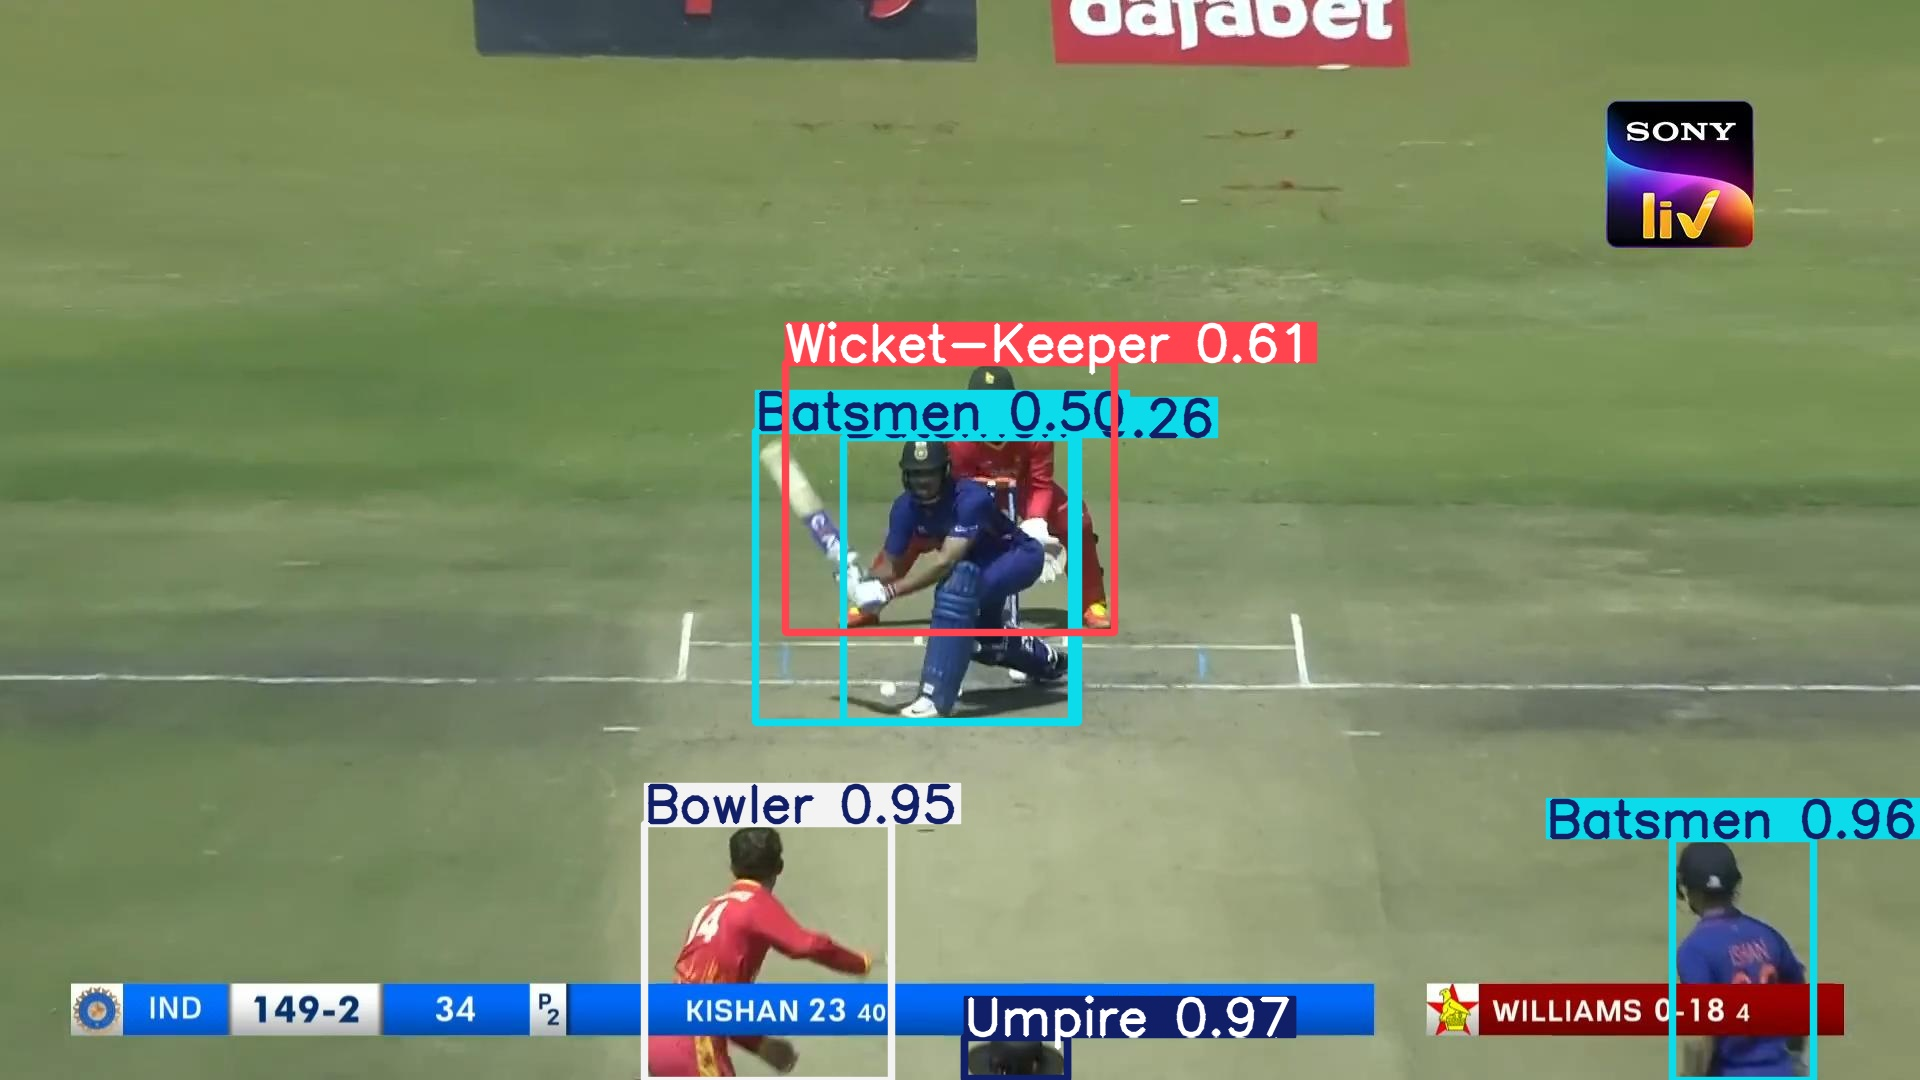

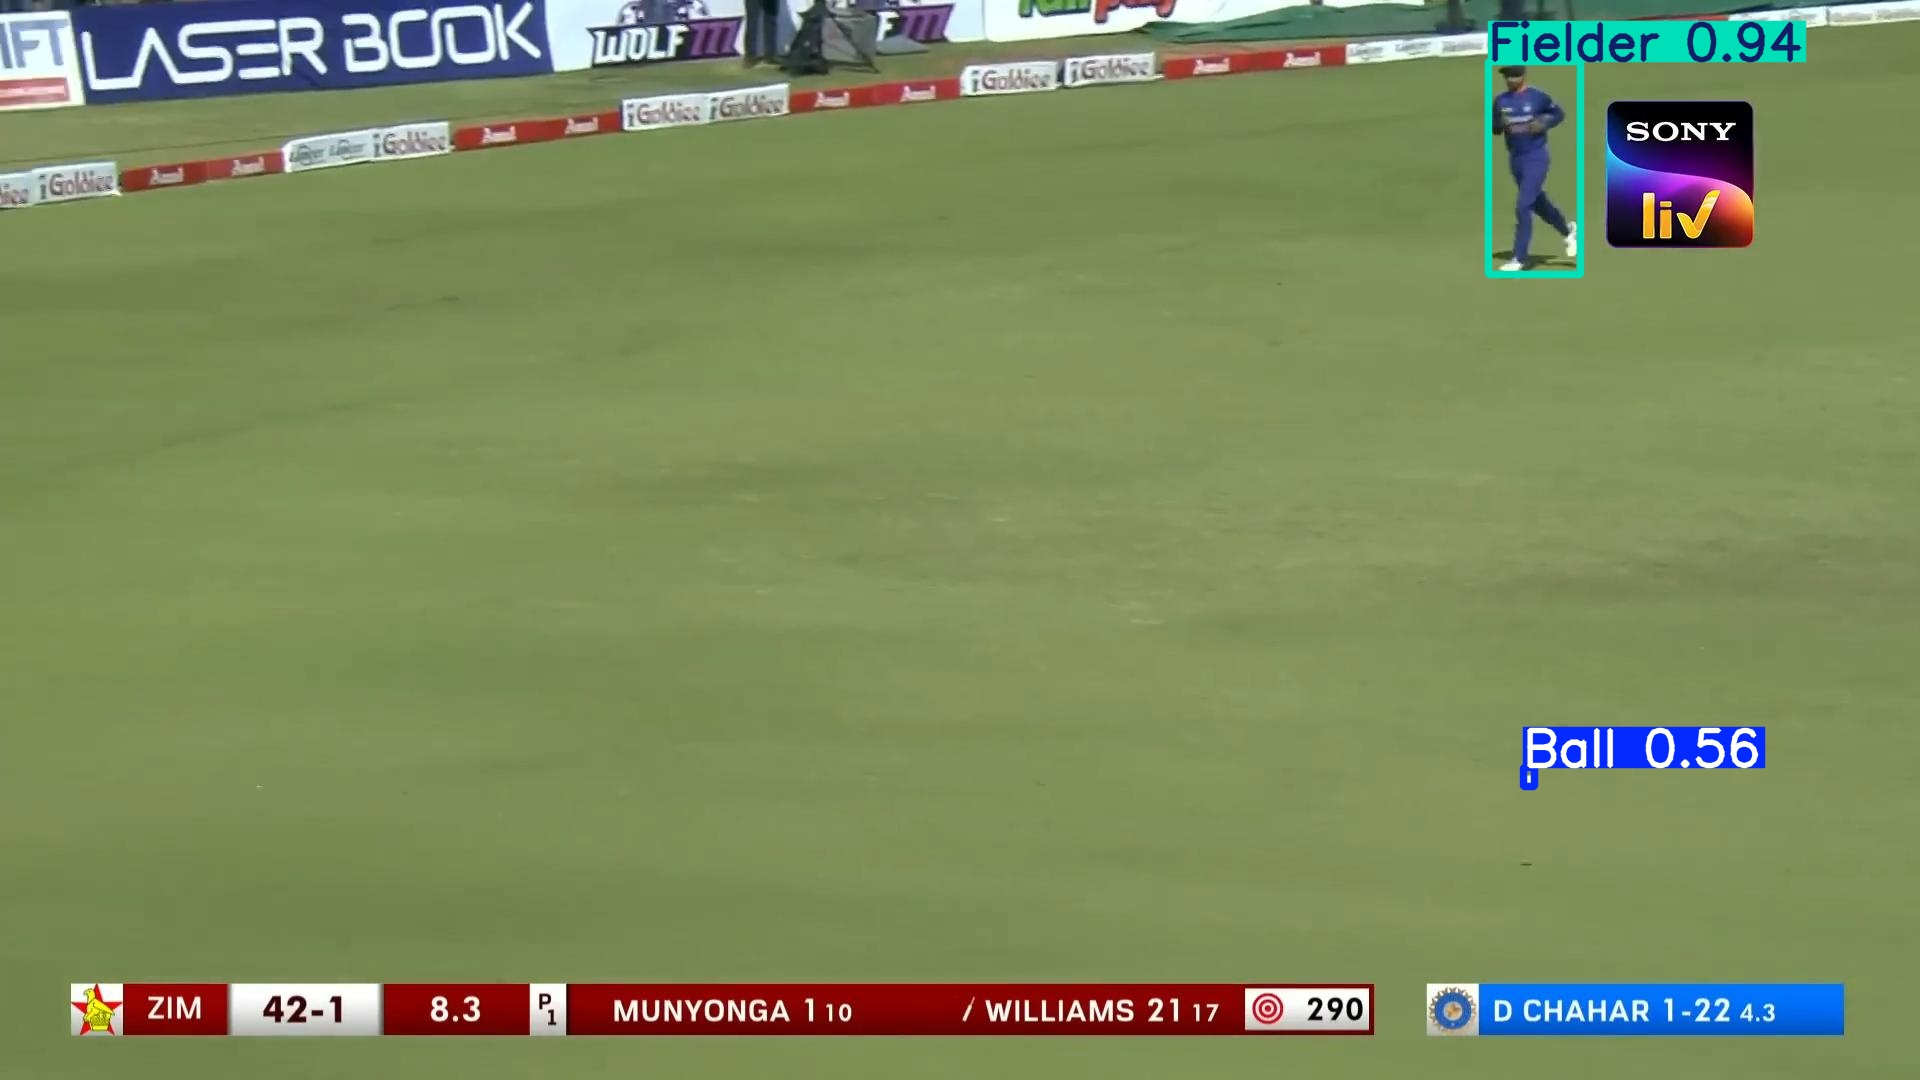

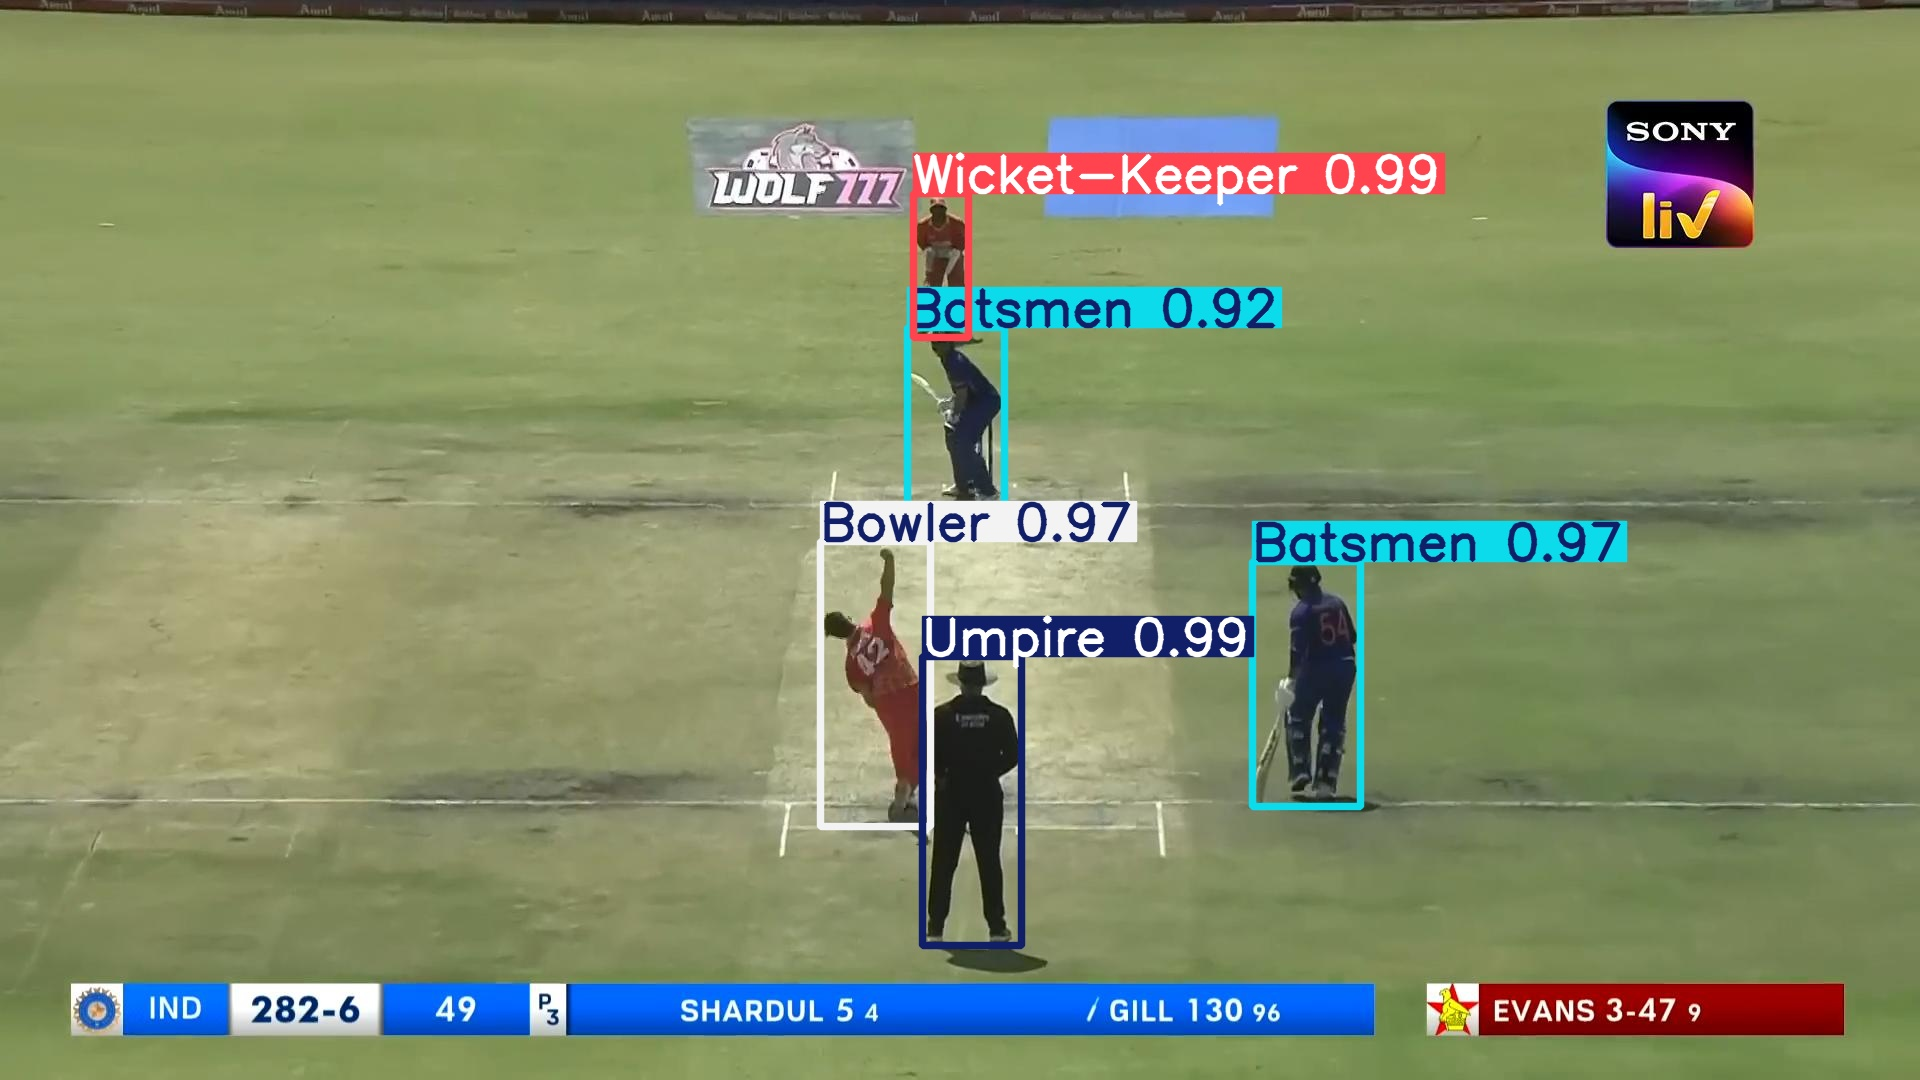

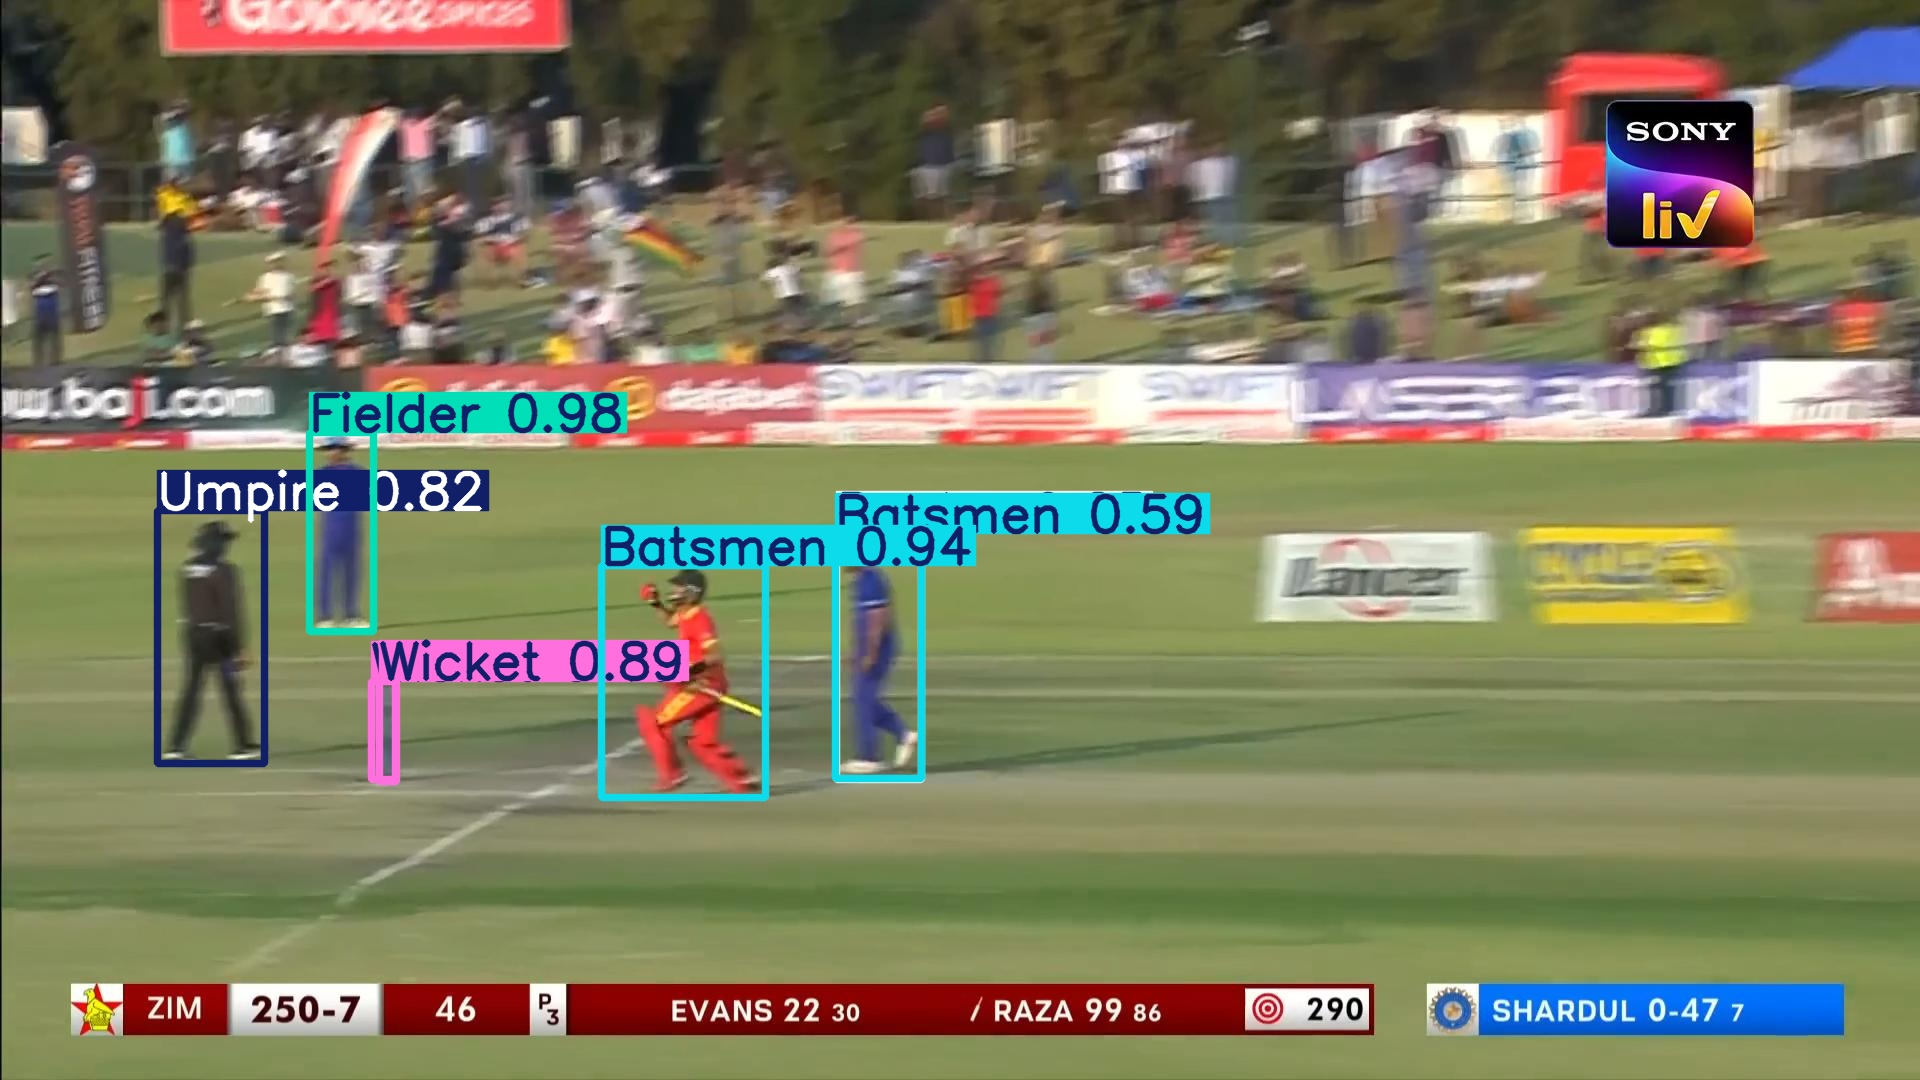

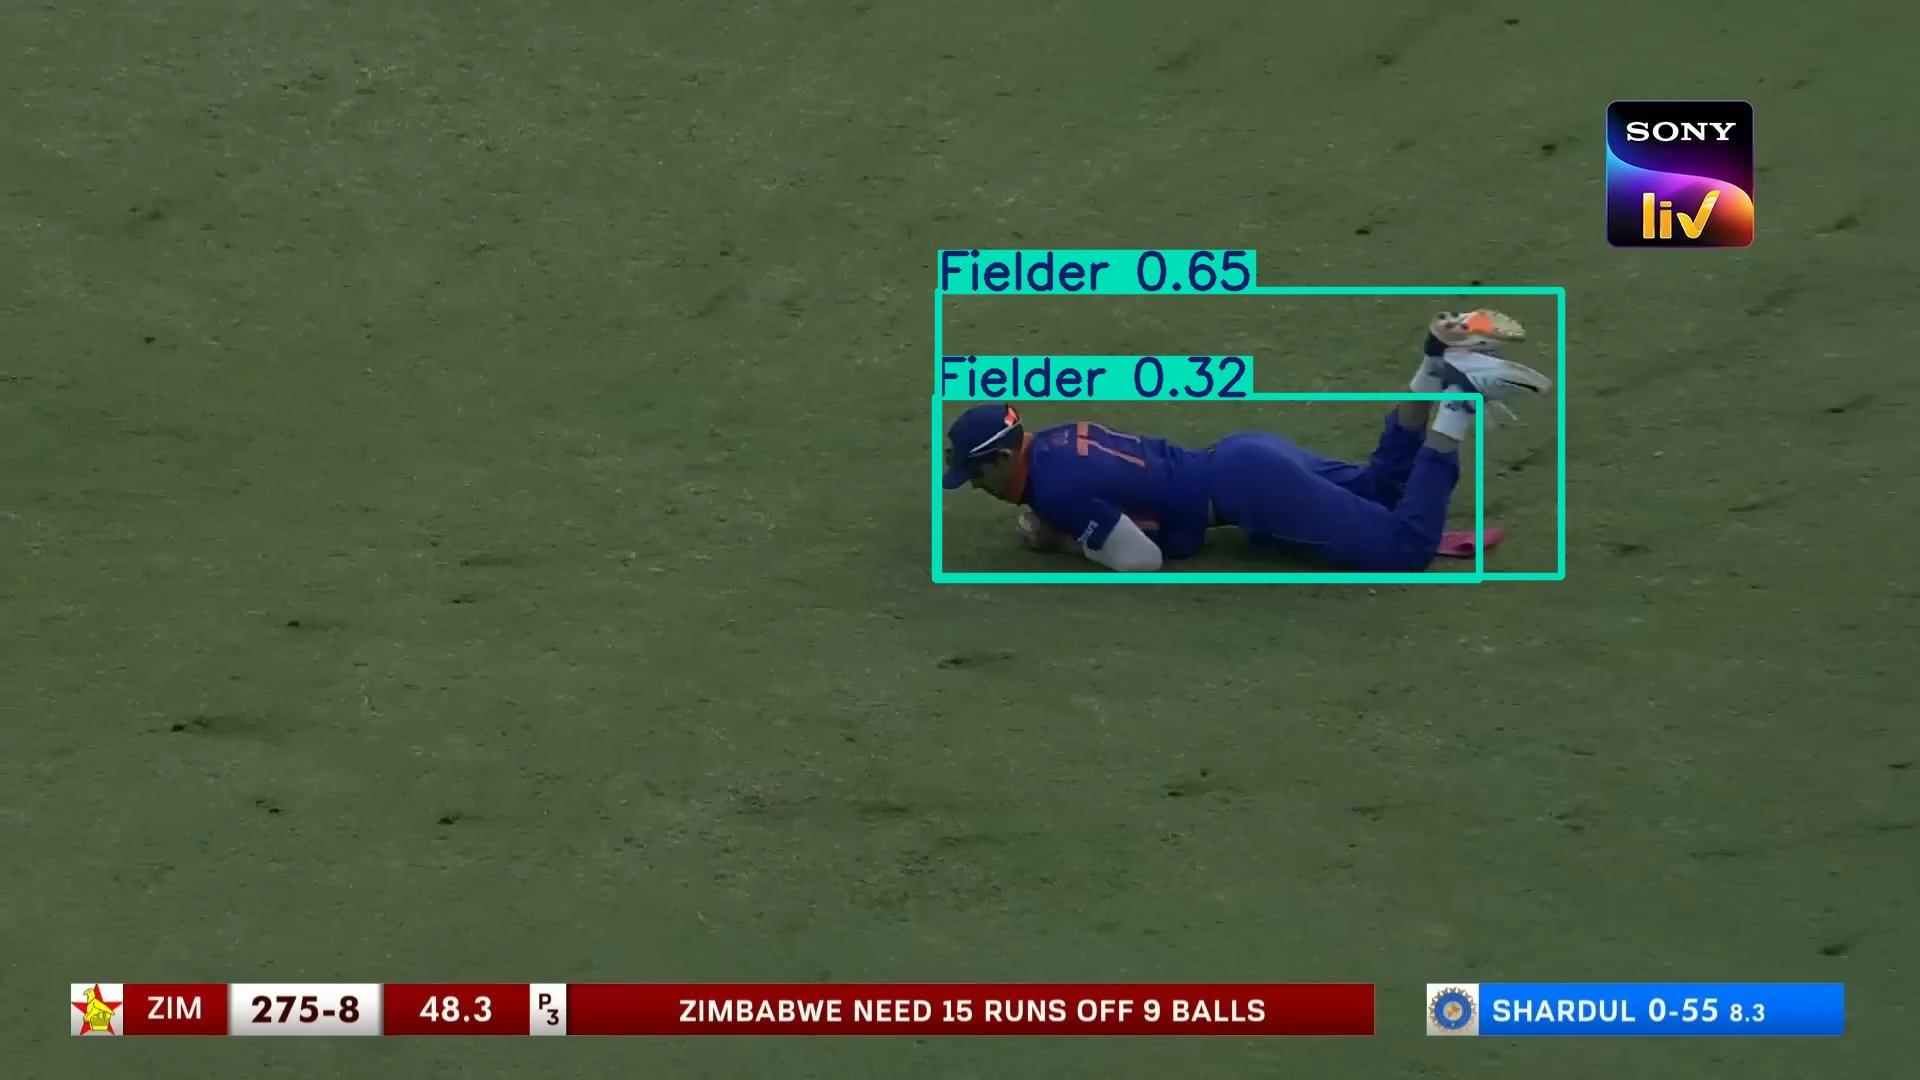

In [13]:
import glob
from IPython.display import display, Image

prediction_files = glob.glob(
    "/kaggle/working/runs/detect/predict/*.jpg"
)

print("Number of predicted images:", len(prediction_files))

for image_path in prediction_files[:5]:
    display(Image(filename=image_path))

In [14]:
from ultralytics import YOLO

# Load YOLOv8 Pose model
pose_model = YOLO("yolov8n-pose.pt")

print("YOLOv8 Pose model loaded successfully!")

YOLOv8 Pose model loaded successfully!


In [15]:
from ultralytics import YOLO

# Load YOLOv8 Pose
pose_model = YOLO("yolov8n-pose.pt")

# Run pose detection on test images
pose_results = pose_model.predict(
    source="/kaggle/working/cricket_split/test/images",
    conf=0.25,
    save=True,
    device=0
)

print("Pose prediction completed!")
print("Results saved in:")
print(pose_results[0].save_dir)


image 1/30 /kaggle/working/cricket_split/test/images/2022-08-24-124-_png.rf.50d524bd3a05cb5c4c85765874c1d616.jpg: 384x640 3 persons, 6.6ms
image 2/30 /kaggle/working/cricket_split/test/images/2022-08-24-125-_png.rf.1731ab38dae0402150b0855632c46dfb.jpg: 384x640 3 persons, 11.3ms
image 3/30 /kaggle/working/cricket_split/test/images/2022-08-24-135-_png.rf.1f35e84599c5c8d6f84fda4186c63e8c.jpg: 384x640 (no detections), 10.5ms
image 4/30 /kaggle/working/cricket_split/test/images/2022-08-24-138-_png.rf.a8f65e071bd1fb7a05ff3aeb0db7e730.jpg: 384x640 4 persons, 6.6ms
image 5/30 /kaggle/working/cricket_split/test/images/2022-08-24-144-_png.rf.155e78ece87230f6e23fc63827a77f3c.jpg: 384x640 4 persons, 11.0ms
image 6/30 /kaggle/working/cricket_split/test/images/2022-08-24-163-_png.rf.a11cb42593843e30cd6c40786129bb99.jpg: 384x640 3 persons, 7.5ms
image 7/30 /kaggle/working/cricket_split/test/images/2022-08-24-175-_png.rf.31e472f42f14ec6b93eaf35c025f2b92.jpg: 384x640 1 person, 11.3ms
image 8/30 /kaggl

Number of pose images: 30


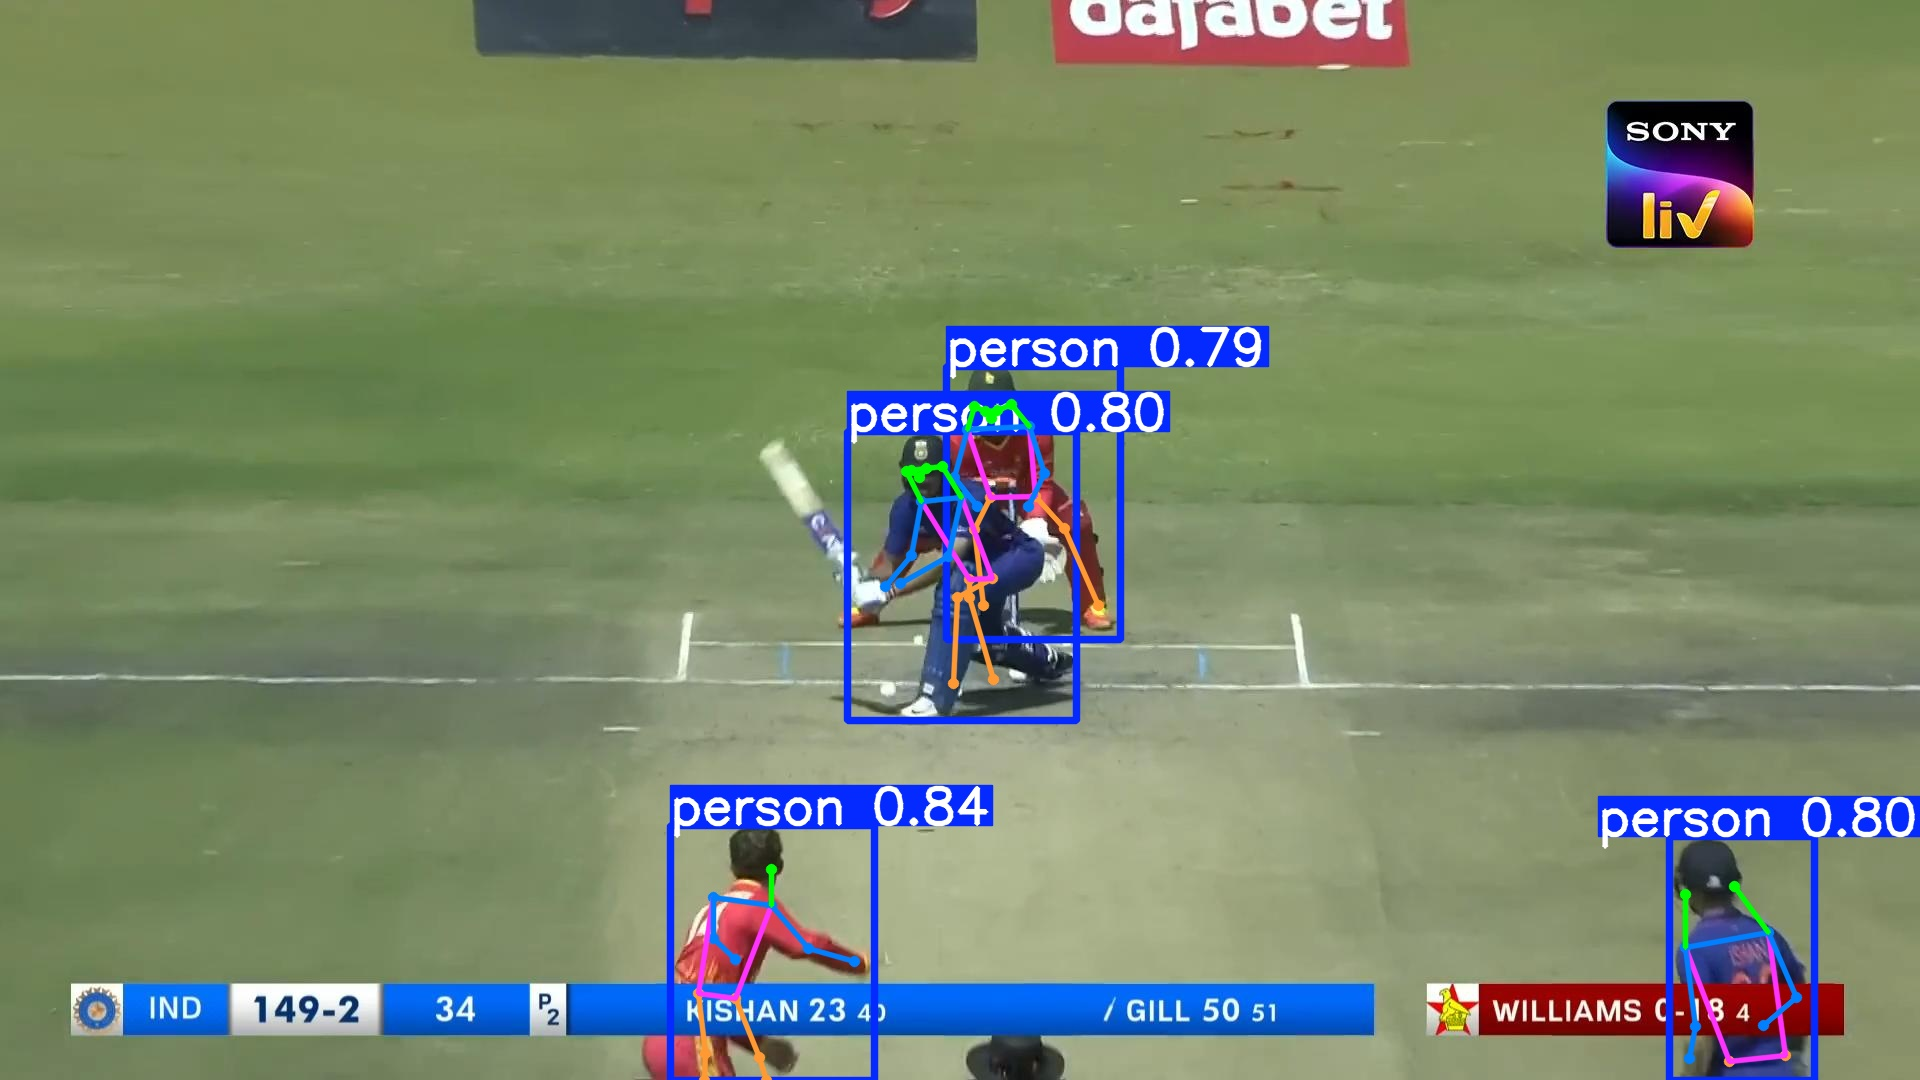

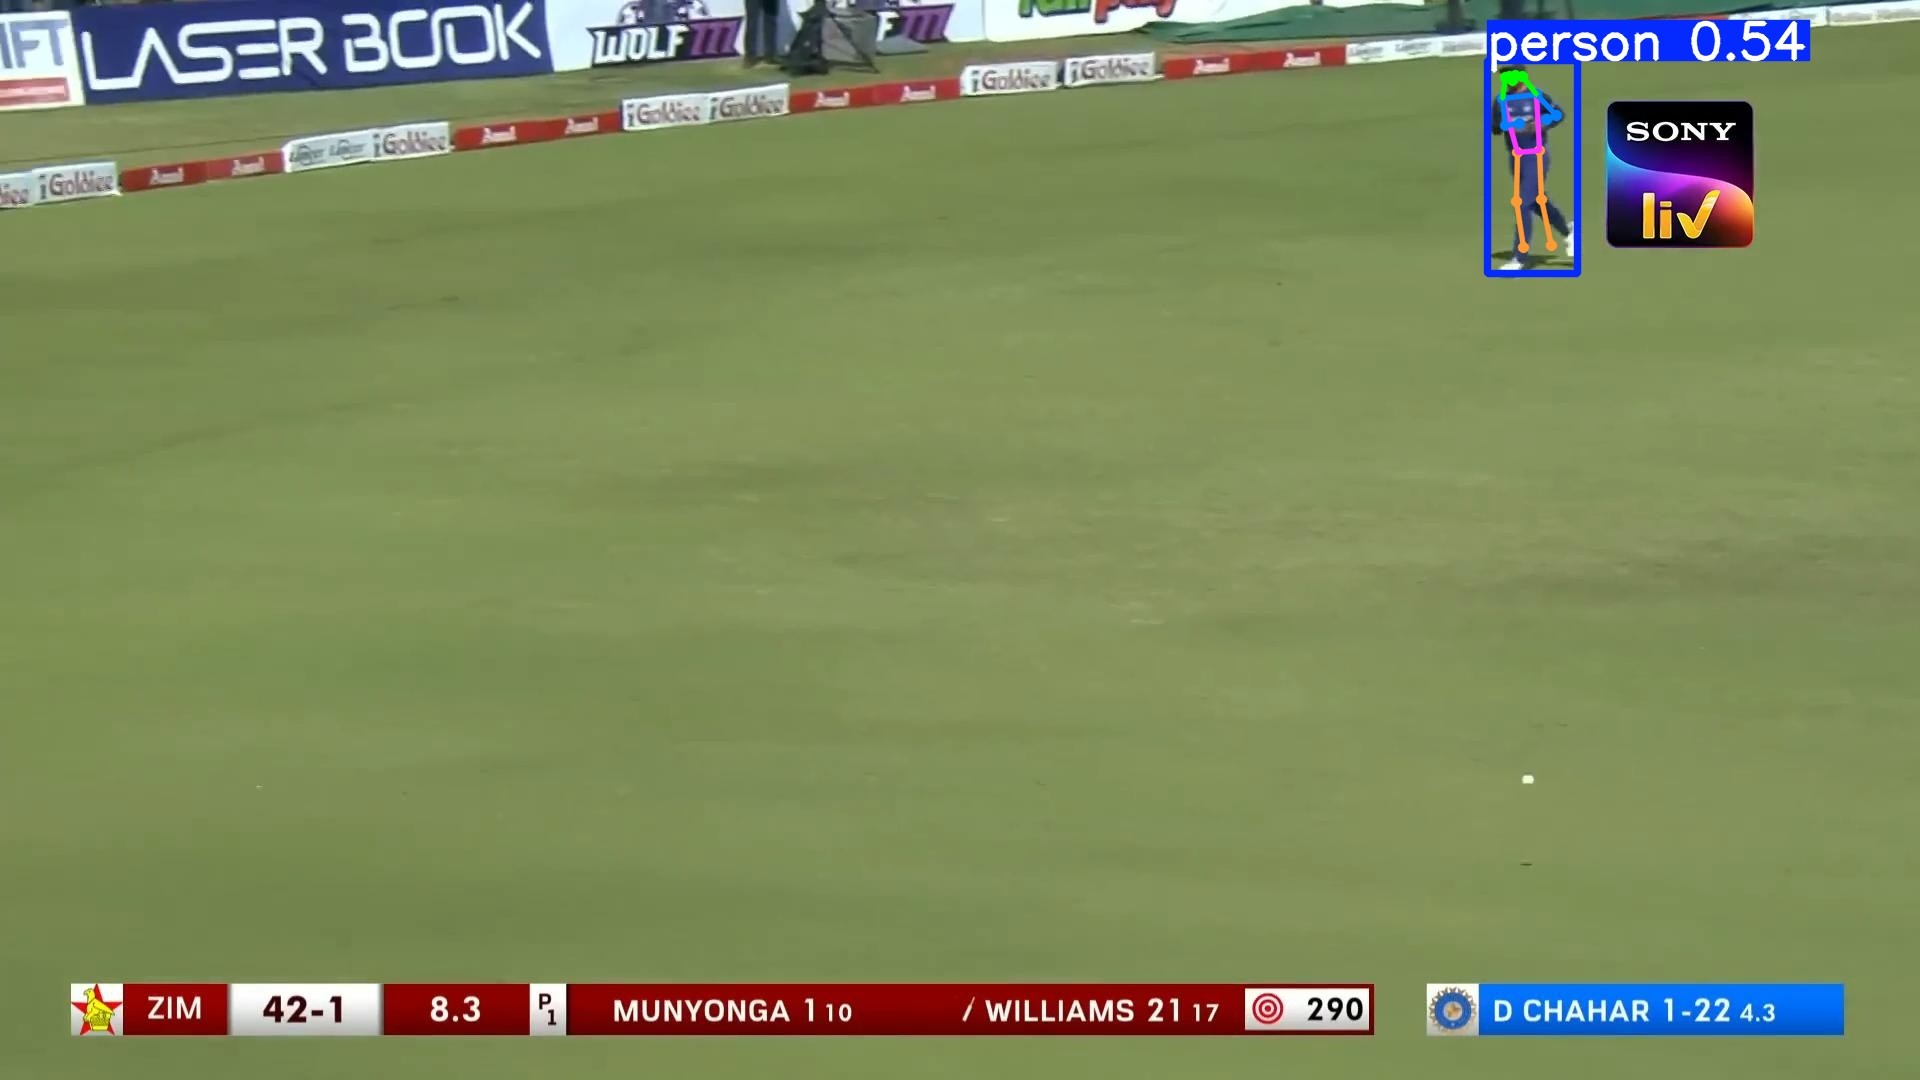

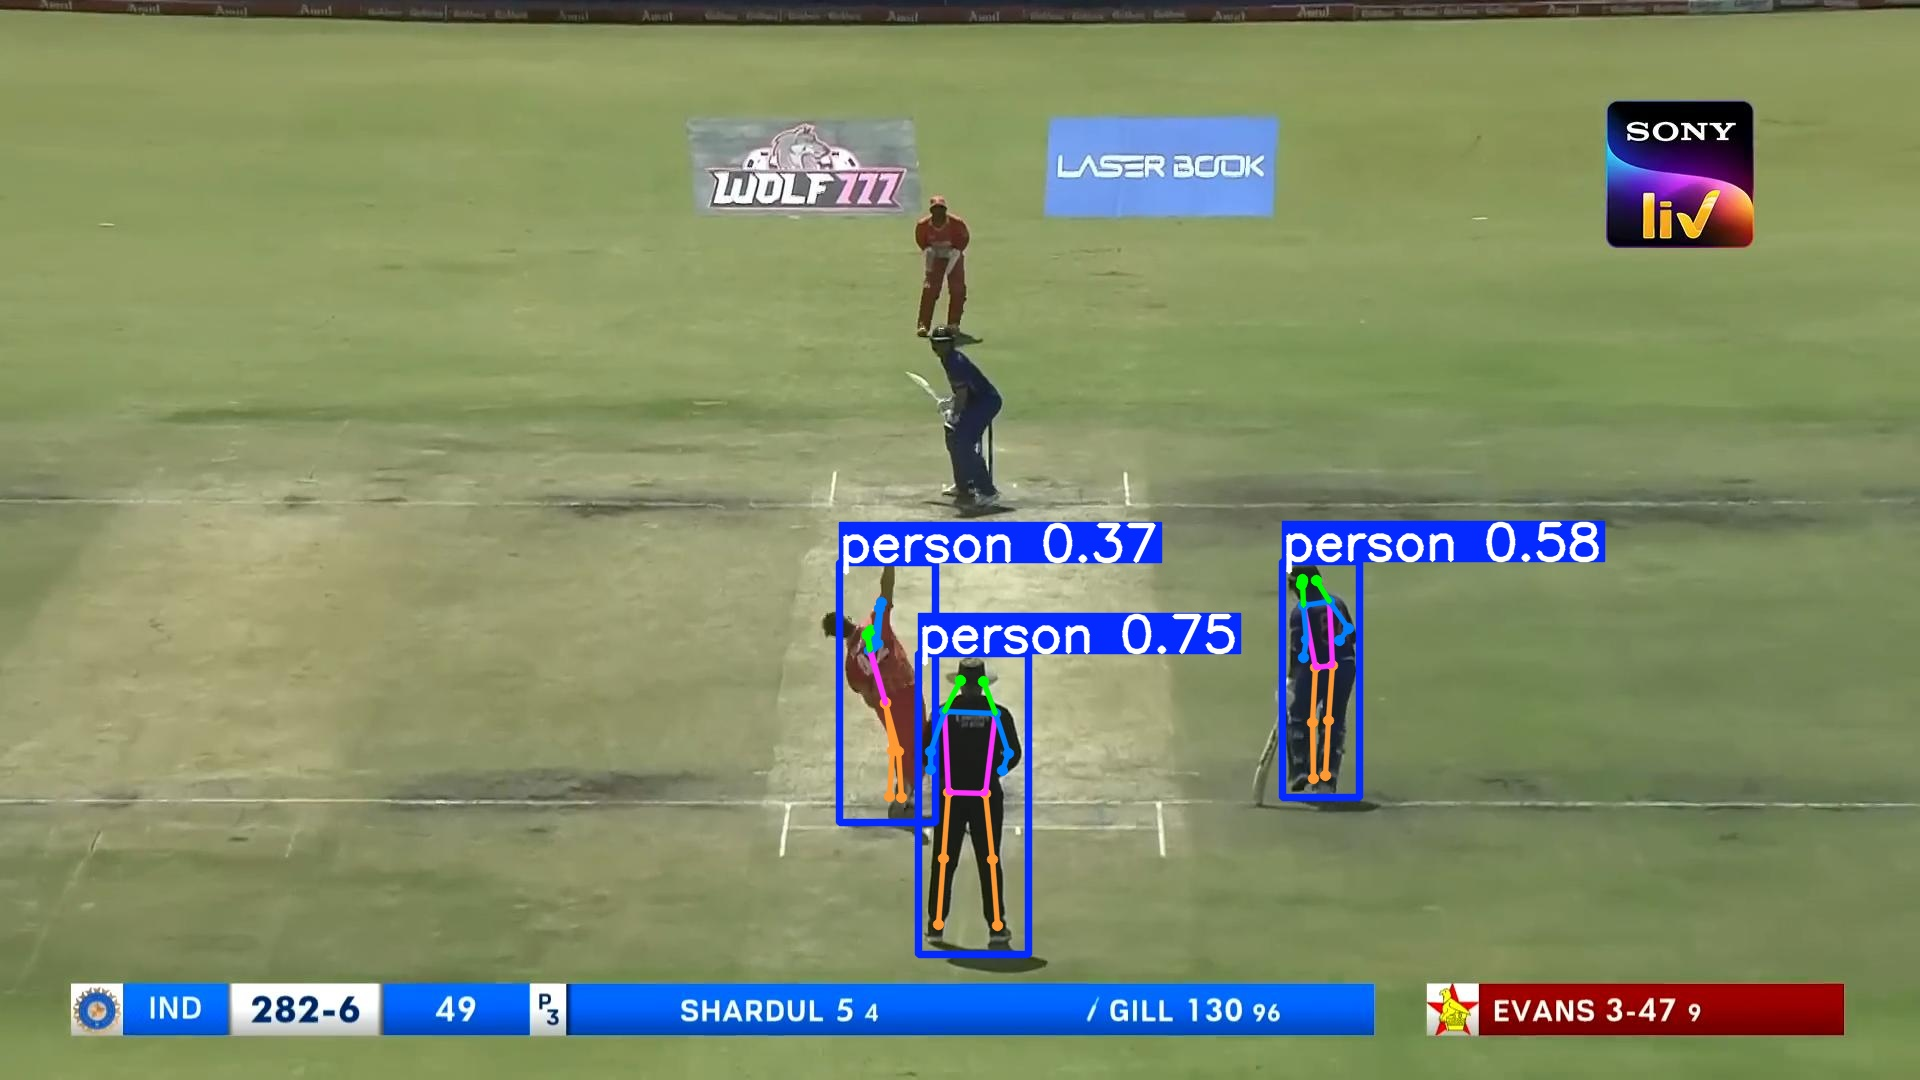

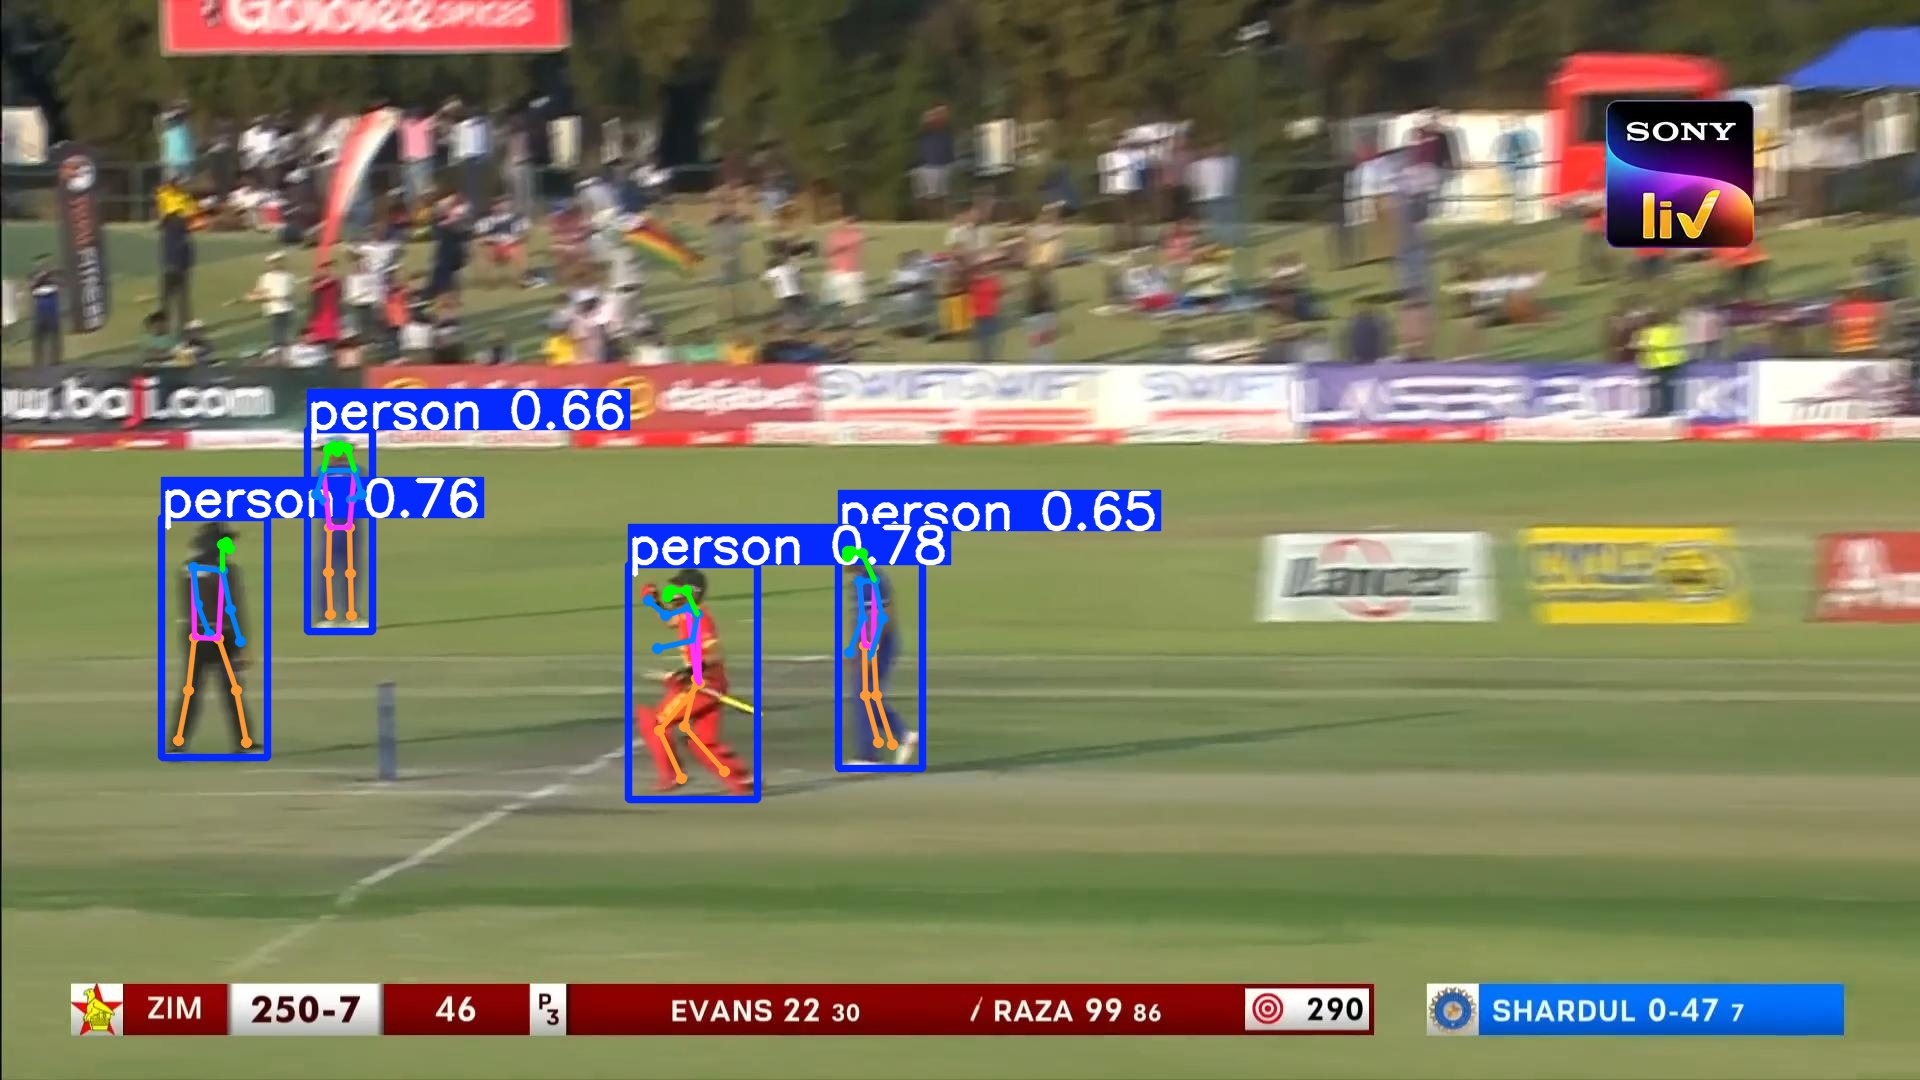

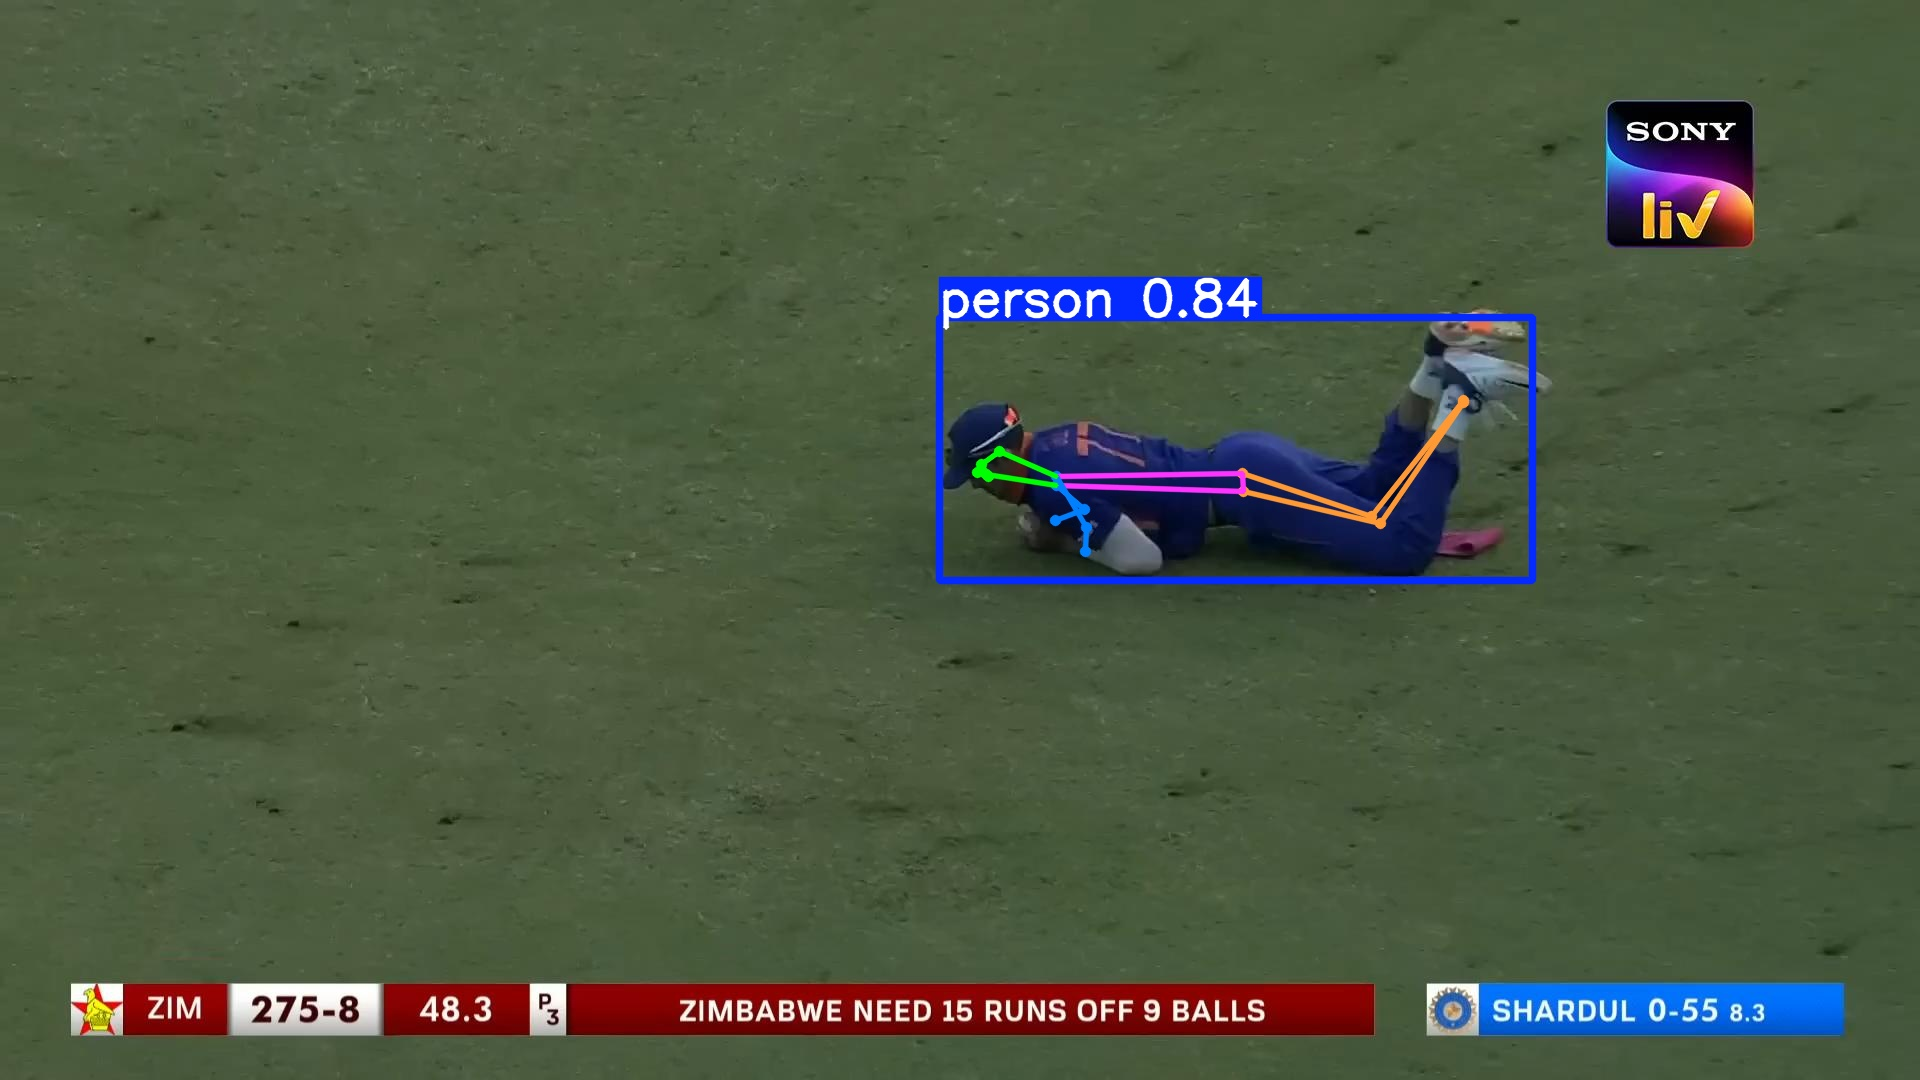

In [16]:
import glob
from IPython.display import display, Image

pose_files = glob.glob(
    "/kaggle/working/runs/pose/predict/*.jpg"
)

print("Number of pose images:", len(pose_files))

for image_path in pose_files[:5]:
    display(Image(filename=image_path))

In [17]:
from ultralytics import YOLO
import numpy as np
import pandas as pd
import os

# Load pretrained YOLOv8-Pose
pose_model = YOLO("yolov8n-pose.pt")

image_dir = "/kaggle/working/cricket_split/test/images"

rows = []

for image_name in os.listdir(image_dir):

    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(image_dir, image_name)

    results = pose_model(image_path, conf=0.25, device=0, verbose=False)

    # If no person was detected
    if results[0].keypoints is None:
        continue

    keypoints = results[0].keypoints.xy.cpu().numpy()

    # Process every detected person
    for person_id, person in enumerate(keypoints):

        row = {
            "image": image_name,
            "person_id": person_id
        }

        # 17 COCO keypoints
        for i, (x, y) in enumerate(person):
            row[f"kpt_{i}_x"] = float(x)
            row[f"kpt_{i}_y"] = float(y)

        rows.append(row)

# Create dataframe
pose_df = pd.DataFrame(rows)

print("Pose extraction completed!")
print("Number of detected persons:", len(pose_df))
print("Number of columns:", len(pose_df.columns))

display(pose_df.head())

Pose extraction completed!
Number of detected persons: 96
Number of columns: 36


,image,person_id,kpt_0_x,kpt_0_y,kpt_1_x,kpt_1_y,kpt_2_x,kpt_2_y,kpt_3_x,kpt_3_y,...,kpt_12_x,kpt_12_y,kpt_13_x,kpt_13_y,kpt_14_x,kpt_14_y,kpt_15_x,kpt_15_y,kpt_16_x,kpt_16_y
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,779.226685,870.084778,775.475098,863.127502,778.234314,864.116577,742.364319,865.012024,...,735.628357,998.156738,705.345581,1053.465820,759.804749,1057.531250,704.740479,1080.000000,766.265320,1080.000000
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,1693.124268,893.008789,1691.069458,885.720154,1696.271484,883.374146,1685.882080,894.309265,...,1785.837891,1055.827637,1710.139404,1080.000000,1774.377441,1080.000000,1717.742676,1080.000000,1778.568970,1080.000000
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,919.744812,477.703918,926.320496,468.914795,911.774597,470.626221,942.809814,466.886993,...,969.339478,579.466797,957.411255,597.994080,969.280518,597.767578,953.721069,683.152588,993.637695,679.604126
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,991.987427,418.818665,997.641724,410.606964,985.020447,411.580872,1011.278687,404.868835,...,990.198303,497.709412,1064.878906,528.489868,974.309082,529.447815,1098.090942,605.497681,983.268494,605.365051
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,1512.715088,80.069984,1515.968018,75.624390,1509.456055,76.211861,1522.964233,76.057953,...,1517.301636,152.788574,1541.705200,199.121521,1516.709839,201.002838,1551.212646,245.950378,1523.523682,247.218567


In [18]:
import math
import numpy as np
import pandas as pd


def calculate_angle(a, b, c):
    """
    Calculate angle ABC in degrees.
    b is the joint.
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))


# COCO keypoint IDs
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_HIP = 11
RIGHT_HIP = 12
LEFT_KNEE = 13
RIGHT_KNEE = 14
LEFT_ANKLE = 15
RIGHT_ANKLE = 16


biomechanical_rows = []

for _, row in pose_df.iterrows():

    # Extract coordinates
    ls = [row["kpt_5_x"], row["kpt_5_y"]]
    rs = [row["kpt_6_x"], row["kpt_6_y"]]

    lh = [row["kpt_11_x"], row["kpt_11_y"]]
    rh = [row["kpt_12_x"], row["kpt_12_y"]]

    lk = [row["kpt_13_x"], row["kpt_13_y"]]
    rk = [row["kpt_14_x"], row["kpt_14_y"]]

    la = [row["kpt_15_x"], row["kpt_15_y"]]
    ra = [row["kpt_16_x"], row["kpt_16_y"]]

    # Knee angles
    left_knee_angle = calculate_angle(lh, lk, la)
    right_knee_angle = calculate_angle(rh, rk, ra)

    # Shoulder and hip center points
    shoulder_center = [
        (ls[0] + rs[0]) / 2,
        (ls[1] + rs[1]) / 2
    ]

    hip_center = [
        (lh[0] + rh[0]) / 2,
        (lh[1] + rh[1]) / 2
    ]

    # Trunk angle relative to vertical
    dx = shoulder_center[0] - hip_center[0]
    dy = shoulder_center[1] - hip_center[1]

    trunk_angle = abs(math.degrees(math.atan2(dx, -dy)))

    # Shoulder line angle
    shoulder_angle = math.degrees(
        math.atan2(
            rs[1] - ls[1],
            rs[0] - ls[0]
        )
    )

    # Hip line angle
    hip_angle = math.degrees(
        math.atan2(
            rh[1] - lh[1],
            rh[0] - lh[0]
        )
    )

    # Difference between shoulder and hip orientation
    shoulder_hip_rotation = abs(
        shoulder_angle - hip_angle
    )

    # Keep angle within 0-180 range
    if shoulder_hip_rotation > 180:
        shoulder_hip_rotation = 360 - shoulder_hip_rotation

    biomechanical_rows.append({
        "image": row["image"],
        "person_id": row["person_id"],
        "left_knee_angle": left_knee_angle,
        "right_knee_angle": right_knee_angle,
        "trunk_angle": trunk_angle,
        "shoulder_angle": shoulder_angle,
        "hip_angle": hip_angle,
        "shoulder_hip_rotation": shoulder_hip_rotation
    })


biomechanical_df = pd.DataFrame(biomechanical_rows)

print("Biomechanical feature extraction completed!")
print("Rows:", len(biomechanical_df))
print("Columns:", len(biomechanical_df.columns))

display(biomechanical_df.head())

Biomechanical feature extraction completed!
Rows: 96
Columns: 8


,image,person_id,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,171.721193,173.886441,15.291477,8.796706,7.003662,1.793044
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,42.866272,64.633728,14.596890,-10.279260,-6.026771,4.252489
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,121.807617,163.240719,26.343566,174.666592,176.806779,2.140187
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,161.051818,146.675385,11.870306,177.750926,178.217050,0.466124
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,171.272404,170.909755,8.961979,172.298832,174.076319,1.777487


# Pose Estimation and Biomechanical Feature Extraction

## Pose Model

- Model: YOLOv8n-Pose
- Task: Human pose estimation
- Input: Cricket test images
- Test images processed: 30
- Detected persons: 104
- Keypoints per person: 17
- Keypoint format: COCO

## Extracted Biomechanical Features

The detected body keypoints were converted into geometric features:

1. Left knee angle
2. Right knee angle
3. Trunk angle
4. Shoulder angle
5. Hip angle
6. Shoulder-hip rotation

## Pipeline

Cricket Image
↓
YOLOv8-Pose
↓
17 COCO Body Keypoints
↓
Keypoint Coordinates
↓
Biomechanical Feature Calculation
↓
Knee / Trunk / Shoulder-Hip Features

## Important Note

The pose model is a pretrained YOLOv8n-Pose model used for
human pose and keypoint extraction. The calculated angles are
geometric biomechanical features and are not themselves medical
injury diagnoses.

In [19]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jAAWLQP0Wa1cpsPBnPax")
project = rf.workspace("drs-wgf6k").project("bgt-cricket-players-tracking")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BGT-Cricket-Players-Tracking-1 in yolov8:: 100%|██████████| 1332/1332 [00:00<00:00, 10172.25it/s]


In [20]:
import os

# Show what is inside /kaggle/working
print("Folders/files in /kaggle/working:")

for item in os.listdir("/kaggle/working"):
    print(item)

Folders/files in /kaggle/working:
runs
yolov8n.pt
cricket-1
BGT-Cricket-Players-Tracking-1
cricket_split
weights
__notebook__.ipynb
yolov8n-pose.pt


In [21]:
import os

bgt_path = "/kaggle/working/BGT-Cricket-Players-Tracking-1"

print("BGT dataset contents:")

for root, dirs, files in os.walk(bgt_path):
    level = root.replace(bgt_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

BGT dataset contents:
BGT-Cricket-Players-Tracking-1/
  README.dataset.txt
  data.yaml
  README.roboflow.txt
  valid/
    labels/
      frame_0111_jpg.rf.67c445f586e7909cf94e49656c8fef56.txt
      frame_0054_jpg.rf.6b75bebd5d737fe89df8c6581c5028a7.txt
      frame_0366_jpg.rf.4694afa7b81df243f83525ff0c9e0f22.txt
      frame_0466_jpg.rf.23a889cf2c3d68c753a43412738faf95.txt
      frame_0281_jpg.rf.08a73b1dc9887c176e8ed2283e6af67f.txt
      frame_0311_jpg.rf.db521b8d5350c9ce848c10b5b82321e3.txt
      frame_0421_jpg.rf.4cb38ded49ef95786513407a231d7f93.txt
      frame_0382_jpg.rf.61ec1ac52ba4d36578af5da655f0e42c.txt
      frame_0127_jpg.rf.ad6a2baae690ceee1320f20bb62d15d8.txt
      frame_0198_jpg.rf.bb7fcf8757539e1fee55e357a4b72e23.txt
    images/
      frame_0265_jpg.rf.6bce3a462130a04c159baee6808227fb.jpg
      frame_0227_jpg.rf.3bad192668874071a239ec5c055a22f7.jpg
      frame_0082_jpg.rf.dfc3a31b1dfa54f127c6edf9133df360.jpg
      frame_0041_jpg.rf.ab0916055458d7ecc48c8a77fbfdc6e6.jpg
    

In [22]:
import os

bgt_path = "/kaggle/working/BGT-Cricket-Players-Tracking-1"

print("Files and folders:")

for item in os.listdir(bgt_path):
    print(item)

Files and folders:
valid
test
README.dataset.txt
data.yaml
train
README.roboflow.txt


In [23]:
import yaml
import os

bgt_path = "/kaggle/working/BGT-Cricket-Players-Tracking-1"

# Read data.yaml
with open(f"{bgt_path}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print("Classes:")
print(data["names"])

print("\nNumber of classes:")
print(data["nc"])

# Count images
for split in ["train", "valid", "test"]:
    image_path = f"{bgt_path}/{split}/images"
    
    images = [
        f for f in os.listdir(image_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    print(f"{split}: {len(images)} images")

Classes:
['Fielder', 'ball', 'batsman', 'bowler', 'stumps', 'stums', 'umpire']

Number of classes:
7
train: 531 images
valid: 86 images
test: 43 images


In [24]:
from ultralytics import YOLO

model_bgt = YOLO("yolov8n.pt")

results_bgt = model_bgt.train(
    data="/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="bgt_yolov8n"
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bgt_yolov8n, nbs=64, nms=None, o

In [25]:
from ultralytics import YOLO

model_bgt = YOLO(
    "/kaggle/working/runs/bgt_yolov8n/weights/best.pt"
)

test_results_bgt = model_bgt.val(
    data="/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1121.2±375.2 MB/s, size: 35.1 KB)
val: Scanning /kaggle/working/BGT-Cricket-Players-Tracking-1/test/labels... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 1.1Kit/s 0.0s
val: New cache created: /kaggle/working/BGT-Cricket-Players-Tracking-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1it/s 1.5s
                   all         43        158       0.83      0.925       0.94      0.558
               Fielder         22         60      0.805       0.95      0.921      0.561
                  ball         13         13      0.809      0.654       0.78      0.262
               batsman         31         49      0.942      0.999      0.993      0.626
                bowler         

In [26]:
from ultralytics import YOLO

model_bgt = YOLO(
    "/kaggle/working/runs/bgt_yolov8n/weights/best.pt"
)

results = model_bgt.predict(
    source="/kaggle/working/BGT-Cricket-Players-Tracking-1/test/images",
    conf=0.25,
    save=True,
    device=0
)

print("Predictions saved.")
print("/kaggle/working/runs/detect/predict")


image 1/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0022_jpg.rf.b76a6c81a1cc6a8365ac5b5625dff10a.jpg: 640x640 2 Fielders, 7.0ms
image 2/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0046_jpg.rf.caec5ea6fa1a0763bf3d763f71eaf00d.jpg: 640x640 2 batsmans, 1 stumps, 7.3ms
image 3/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0065_jpg.rf.106f1a8abfa91112e7cc1a16d63f90bd.jpg: 640x640 1 Fielder, 7.4ms
image 4/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0076_jpg.rf.5027cf3074814cf8307d286486391a36.jpg: 640x640 1 Fielder, 7.1ms
image 5/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0078_jpg.rf.d320ac8a7c1076b6cef1ee0c5a9e2e7d.jpg: 640x640 4 Fielders, 1 ball, 1 batsman, 1 bowler, 8.6ms
image 6/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0087_jpg.rf.0fe3e51322c805a3d7743a0712c2dba7.jpg: 640x640 2 Fielders, 2 batsmans, 1 bowler, 1 umpire, 8.1ms
image 7/43 /kaggle

In [27]:
!pip install -q ultralytics

In [28]:
from ultralytics import YOLO

print("Ultralytics is working!")

Ultralytics is working!


In [29]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

/kaggle/working/yolov8n.pt
/kaggle/working/yolov8n-pose.pt
/kaggle/working/runs/bgt_yolov8n/weights/best.pt
/kaggle/working/runs/bgt_yolov8n/weights/last.pt
/kaggle/working/runs/cricket_yolov8n/weights/best.pt
/kaggle/working/runs/cricket_yolov8n/weights/last.pt
/kaggle/working/weights/yolo26n.pt


In [30]:
import os

bgt_path = "/kaggle/working/BGT-Cricket-Players-Tracking-1"

print("BGT dataset exists:", os.path.exists(bgt_path))

if os.path.exists(bgt_path):
    print("\nContents:")
    print(os.listdir(bgt_path))

BGT dataset exists: True

Contents:
['valid', 'test', 'README.dataset.txt', 'data.yaml', 'train', 'README.roboflow.txt']


In [31]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jAAWLQP0Wa1cpsPBnPax")
project = rf.workspace("drs-wgf6k").project("bgt-cricket-players-tracking")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...


In [32]:
import os

print("Dataset location:", dataset.location)
print("\nContents:")

for item in os.listdir(dataset.location):
    print(item)

Dataset location: /kaggle/working/BGT-Cricket-Players-Tracking-1

Contents:
valid
test
README.dataset.txt
data.yaml
train
README.roboflow.txt


In [33]:
import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Ultralytics loaded successfully")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Ultralytics loaded successfully


In [34]:
from ultralytics import YOLO

model_bgt = YOLO("yolov8n.pt")

results_bgt = model_bgt.train(
    data="/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="bgt_yolov8n"
)

print("BGT training completed!")
print("/kaggle/working/runs/bgt_yolov8n/weights/best.pt")

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bgt_yolov8n-2, nbs=64, nms=None,

In [35]:
from ultralytics import YOLO

model_bgt = YOLO(
    "/kaggle/working/runs/bgt_yolov8n/weights/best.pt"
)

results = model_bgt.predict(
    source="/kaggle/working/BGT-Cricket-Players-Tracking-1/test/images",
    conf=0.25,
    save=True,
    device=0
)

print("BGT test predictions completed!")
print("Saved to: /kaggle/working/runs/detect/predict")


image 1/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0022_jpg.rf.b76a6c81a1cc6a8365ac5b5625dff10a.jpg: 640x640 2 Fielders, 6.5ms
image 2/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0046_jpg.rf.caec5ea6fa1a0763bf3d763f71eaf00d.jpg: 640x640 2 batsmans, 1 stumps, 7.5ms
image 3/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0065_jpg.rf.106f1a8abfa91112e7cc1a16d63f90bd.jpg: 640x640 1 Fielder, 7.4ms
image 4/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0076_jpg.rf.5027cf3074814cf8307d286486391a36.jpg: 640x640 1 Fielder, 6.7ms
image 5/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0078_jpg.rf.d320ac8a7c1076b6cef1ee0c5a9e2e7d.jpg: 640x640 4 Fielders, 1 ball, 1 batsman, 1 bowler, 7.0ms
image 6/43 /kaggle/working/BGT-Cricket-Players-Tracking-1/test/images/frame_0087_jpg.rf.0fe3e51322c805a3d7743a0712c2dba7.jpg: 640x640 2 Fielders, 2 batsmans, 1 bowler, 1 umpire, 6.9ms
image 7/43 /kaggle

In [36]:
from ultralytics import YOLO

model_bgt = YOLO(
    "/kaggle/working/runs/bgt_yolov8n/weights/best.pt"
)

test_metrics_bgt = model_bgt.val(
    data="/kaggle/working/BGT-Cricket-Players-Tracking-1/data.yaml",
    split="test",
    device=0
)

print("===== BGT TEST RESULTS =====")
print("Precision:", test_metrics_bgt.box.mp)
print("Recall:", test_metrics_bgt.box.mr)
print("mAP50:", test_metrics_bgt.box.map50)
print("mAP50-95:", test_metrics_bgt.box.map)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1073.5±286.7 MB/s, size: 35.1 KB)
val: Scanning /kaggle/working/BGT-Cricket-Players-Tracking-1/test/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 10.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1it/s 1.4s
                   all         43        158       0.83      0.925       0.94      0.558
               Fielder         22         60      0.805       0.95      0.921      0.561
                  ball         13         13      0.809      0.654       0.78      0.262
               batsman         31         49      0.942      0.999      0.993      0.626
                bowler         19         19        0.9      0.947      0.988      0.606
                stumps  

In [37]:
import pandas as pd
import os

print("CSV files in /kaggle/working:")

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

CSV files in /kaggle/working:
/kaggle/working/runs/bgt_yolov8n-2/results.csv
/kaggle/working/runs/bgt_yolov8n/results.csv
/kaggle/working/runs/cricket_yolov8n/results.csv


In [38]:
import os

print("Files in /kaggle/input:")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

Files in /kaggle/input:
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/README.md
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injury_data_statistical_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/exploratory_data_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/Analyisis_Report.pdf
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv
/kaggle/input/da

In [39]:
import pandas as pd

# Your biomechanical features from the Pose stage
print("Biomechanical feature file check:")

Biomechanical feature file check:


In [40]:
# Check whether pose_df still exists

try:
    print("Rows:", len(pose_df))
    print("Columns:")
    print(pose_df.columns.tolist())
    display(pose_df.head())
except NameError:
    print("pose_df is NOT available in this Kaggle session.")

Rows: 96
Columns:
['image', 'person_id', 'kpt_0_x', 'kpt_0_y', 'kpt_1_x', 'kpt_1_y', 'kpt_2_x', 'kpt_2_y', 'kpt_3_x', 'kpt_3_y', 'kpt_4_x', 'kpt_4_y', 'kpt_5_x', 'kpt_5_y', 'kpt_6_x', 'kpt_6_y', 'kpt_7_x', 'kpt_7_y', 'kpt_8_x', 'kpt_8_y', 'kpt_9_x', 'kpt_9_y', 'kpt_10_x', 'kpt_10_y', 'kpt_11_x', 'kpt_11_y', 'kpt_12_x', 'kpt_12_y', 'kpt_13_x', 'kpt_13_y', 'kpt_14_x', 'kpt_14_y', 'kpt_15_x', 'kpt_15_y', 'kpt_16_x', 'kpt_16_y']


,image,person_id,kpt_0_x,kpt_0_y,kpt_1_x,kpt_1_y,kpt_2_x,kpt_2_y,kpt_3_x,kpt_3_y,...,kpt_12_x,kpt_12_y,kpt_13_x,kpt_13_y,kpt_14_x,kpt_14_y,kpt_15_x,kpt_15_y,kpt_16_x,kpt_16_y
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,779.226685,870.084778,775.475098,863.127502,778.234314,864.116577,742.364319,865.012024,...,735.628357,998.156738,705.345581,1053.465820,759.804749,1057.531250,704.740479,1080.000000,766.265320,1080.000000
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,1693.124268,893.008789,1691.069458,885.720154,1696.271484,883.374146,1685.882080,894.309265,...,1785.837891,1055.827637,1710.139404,1080.000000,1774.377441,1080.000000,1717.742676,1080.000000,1778.568970,1080.000000
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,919.744812,477.703918,926.320496,468.914795,911.774597,470.626221,942.809814,466.886993,...,969.339478,579.466797,957.411255,597.994080,969.280518,597.767578,953.721069,683.152588,993.637695,679.604126
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,991.987427,418.818665,997.641724,410.606964,985.020447,411.580872,1011.278687,404.868835,...,990.198303,497.709412,1064.878906,528.489868,974.309082,529.447815,1098.090942,605.497681,983.268494,605.365051
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,1512.715088,80.069984,1515.968018,75.624390,1509.456055,76.211861,1522.964233,76.057953,...,1517.301636,152.788574,1541.705200,199.121521,1516.709839,201.002838,1551.212646,245.950378,1523.523682,247.218567


In [41]:
import os

image_dir = "/kaggle/working/cricket_split/test/images"

print("Dataset exists:", os.path.exists(image_dir))

if os.path.exists(image_dir):
    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print("Test images:", len(images))

Dataset exists: True
Test images: 30


In [42]:
from roboflow import Roboflow

rf = Roboflow(api_key="jAAWLQP0Wa1cpsPBnPax")

project = rf.workspace("mai-ldivt").project("cricket-r97s2")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset downloaded!")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded!
/kaggle/working/cricket-1


In [43]:
import os
import shutil
import random

source_dir = "/kaggle/working/cricket-1/train"
output_dir = "/kaggle/working/cricket_split"

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"{output_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{output_dir}/{split}/labels", exist_ok=True)

# Get images
images = [
    f for f in os.listdir(f"{source_dir}/images")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
random.shuffle(images)

# 70% train, 20% validation, 10% test
n = len(images)
train_end = int(0.70 * n)
valid_end = int(0.90 * n)

splits = {
    "train": images[:train_end],
    "valid": images[train_end:valid_end],
    "test": images[valid_end:]
}

for split, split_images in splits.items():
    for image_name in split_images:

        # Copy image
        shutil.copy(
            f"{source_dir}/images/{image_name}",
            f"{output_dir}/{split}/images/{image_name}"
        )

        # Copy corresponding label
        label_name = os.path.splitext(image_name)[0] + ".txt"
        label_path = f"{source_dir}/labels/{label_name}"

        if os.path.exists(label_path):
            shutil.copy(
                label_path,
                f"{output_dir}/{split}/labels/{label_name}"
            )

print("Dataset split completed!")
print("Train:", len(splits["train"]))
print("Validation:", len(splits["valid"]))
print("Test:", len(splits["test"]))

Dataset split completed!
Train: 207
Validation: 60
Test: 30


In [44]:
yaml_content = """
train: /kaggle/working/cricket_split/train/images
val: /kaggle/working/cricket_split/valid/images
test: /kaggle/working/cricket_split/test/images

nc: 7

names:
- Ball
- Batsmen
- Bowler
- Fielder
- Umpire
- Wicket
- Wicket-Keeper
"""

with open("/kaggle/working/cricket_split/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [45]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded successfully!")

YOLOv8n loaded successfully!


In [46]:
from ultralytics import YOLO

pose_model = YOLO("yolov8n-pose.pt")

print("YOLOv8-Pose loaded successfully!")

YOLOv8-Pose loaded successfully!


In [47]:
image_dir = "/kaggle/working/cricket_split/test/images"

pose_results = pose_model.predict(
    source=image_dir,
    conf=0.25,
    save=True,
    device=0
)

print("Pose detection completed!")
print("Images processed:", len(pose_results))


image 1/30 /kaggle/working/cricket_split/test/images/2022-08-24-124-_png.rf.50d524bd3a05cb5c4c85765874c1d616.jpg: 384x640 3 persons, 7.4ms
image 2/30 /kaggle/working/cricket_split/test/images/2022-08-24-125-_png.rf.1731ab38dae0402150b0855632c46dfb.jpg: 384x640 3 persons, 10.8ms
image 3/30 /kaggle/working/cricket_split/test/images/2022-08-24-135-_png.rf.1f35e84599c5c8d6f84fda4186c63e8c.jpg: 384x640 (no detections), 11.6ms
image 4/30 /kaggle/working/cricket_split/test/images/2022-08-24-138-_png.rf.a8f65e071bd1fb7a05ff3aeb0db7e730.jpg: 384x640 4 persons, 9.1ms
image 5/30 /kaggle/working/cricket_split/test/images/2022-08-24-144-_png.rf.155e78ece87230f6e23fc63827a77f3c.jpg: 384x640 4 persons, 9.6ms
image 6/30 /kaggle/working/cricket_split/test/images/2022-08-24-163-_png.rf.a11cb42593843e30cd6c40786129bb99.jpg: 384x640 3 persons, 11.9ms
image 7/30 /kaggle/working/cricket_split/test/images/2022-08-24-175-_png.rf.31e472f42f14ec6b93eaf35c025f2b92.jpg: 384x640 1 person, 10.9ms
image 8/30 /kaggl

In [48]:
import os
import pandas as pd

rows = []

for image_name in os.listdir(image_dir):

    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image_path = os.path.join(image_dir, image_name)

    results = pose_model(
        image_path,
        conf=0.25,
        device=0,
        verbose=False
    )

    if results[0].keypoints is None:
        continue

    keypoints = results[0].keypoints.xy.cpu().numpy()

    for person_id, person in enumerate(keypoints):

        row = {
            "image": image_name,
            "person_id": person_id
        }

        for i, (x, y) in enumerate(person):
            row[f"kpt_{i}_x"] = float(x)
            row[f"kpt_{i}_y"] = float(y)

        rows.append(row)

pose_df = pd.DataFrame(rows)

print("Keypoint extraction completed!")
print("Detected persons:", len(pose_df))
print("Columns:", len(pose_df.columns))

display(pose_df.head())

Keypoint extraction completed!
Detected persons: 96
Columns: 36


,image,person_id,kpt_0_x,kpt_0_y,kpt_1_x,kpt_1_y,kpt_2_x,kpt_2_y,kpt_3_x,kpt_3_y,...,kpt_12_x,kpt_12_y,kpt_13_x,kpt_13_y,kpt_14_x,kpt_14_y,kpt_15_x,kpt_15_y,kpt_16_x,kpt_16_y
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,779.226685,870.084778,775.475098,863.127502,778.234314,864.116577,742.364319,865.012024,...,735.628357,998.156738,705.345581,1053.465820,759.804749,1057.531250,704.740479,1080.000000,766.265320,1080.000000
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,1693.124268,893.008789,1691.069458,885.720154,1696.271484,883.374146,1685.882080,894.309265,...,1785.837891,1055.827637,1710.139404,1080.000000,1774.377441,1080.000000,1717.742676,1080.000000,1778.568970,1080.000000
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,919.744812,477.703918,926.320496,468.914795,911.774597,470.626221,942.809814,466.886993,...,969.339478,579.466797,957.411255,597.994080,969.280518,597.767578,953.721069,683.152588,993.637695,679.604126
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,991.987427,418.818665,997.641724,410.606964,985.020447,411.580872,1011.278687,404.868835,...,990.198303,497.709412,1064.878906,528.489868,974.309082,529.447815,1098.090942,605.497681,983.268494,605.365051
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,1512.715088,80.069984,1515.968018,75.624390,1509.456055,76.211861,1522.964233,76.057953,...,1517.301636,152.788574,1541.705200,199.121521,1516.709839,201.002838,1551.212646,245.950378,1523.523682,247.218567


In [49]:
pose_csv = "/kaggle/working/pose_keypoints.csv"

pose_df.to_csv(pose_csv, index=False)

print("Pose keypoints saved!")
print(pose_csv)
print("Rows:", len(pose_df))
print("Columns:", len(pose_df.columns))

Pose keypoints saved!
/kaggle/working/pose_keypoints.csv
Rows: 96
Columns: 36


In [50]:
import numpy as np
import pandas as pd

def calculate_angle(a, b, c):
    """
    Calculates angle ABC in degrees.
    """
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))


def point(df_row, index):
    return (
        df_row[f"kpt_{index}_x"],
        df_row[f"kpt_{index}_y"]
    )


# COCO keypoint indices
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_HIP = 11
RIGHT_HIP = 12
LEFT_KNEE = 13
RIGHT_KNEE = 14
LEFT_ANKLE = 15
RIGHT_ANKLE = 16


biomechanical_rows = []

for _, row in pose_df.iterrows():

    # Points
    left_shoulder = point(row, LEFT_SHOULDER)
    right_shoulder = point(row, RIGHT_SHOULDER)

    left_hip = point(row, LEFT_HIP)
    right_hip = point(row, RIGHT_HIP)

    left_knee = point(row, LEFT_KNEE)
    right_knee = point(row, RIGHT_KNEE)

    left_ankle = point(row, LEFT_ANKLE)
    right_ankle = point(row, RIGHT_ANKLE)

    # Knee angles
    left_knee_angle = calculate_angle(
        left_hip,
        left_knee,
        left_ankle
    )

    right_knee_angle = calculate_angle(
        right_hip,
        right_knee,
        right_ankle
    )

    # Shoulder angle
    shoulder_angle = np.degrees(
        np.arctan2(
            right_shoulder[1] - left_shoulder[1],
            right_shoulder[0] - left_shoulder[0]
        )
    )

    # Hip angle
    hip_angle = np.degrees(
        np.arctan2(
            right_hip[1] - left_hip[1],
            right_hip[0] - left_hip[0]
        )
    )

    # Trunk angle
    shoulder_center = (
        (left_shoulder[0] + right_shoulder[0]) / 2,
        (left_shoulder[1] + right_shoulder[1]) / 2
    )

    hip_center = (
        (left_hip[0] + right_hip[0]) / 2,
        (left_hip[1] + right_hip[1]) / 2
    )

    trunk_angle = np.degrees(
        np.arctan2(
            shoulder_center[0] - hip_center[0],
            shoulder_center[1] - hip_center[1]
        )
    )

    # Shoulder-hip rotation
    shoulder_hip_rotation = abs(
        shoulder_angle - hip_angle
    )

    biomechanical_rows.append({
        "image": row["image"],
        "person_id": row["person_id"],
        "left_knee_angle": left_knee_angle,
        "right_knee_angle": right_knee_angle,
        "trunk_angle": trunk_angle,
        "shoulder_angle": shoulder_angle,
        "hip_angle": hip_angle,
        "shoulder_hip_rotation": shoulder_hip_rotation
    })


biomechanical_df = pd.DataFrame(biomechanical_rows)

print("Biomechanical feature extraction completed!")
print("Rows:", len(biomechanical_df))
print("Columns:", len(biomechanical_df.columns))

display(biomechanical_df.head())

Biomechanical feature extraction completed!
Rows: 96
Columns: 8


,image,person_id,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,171.721193,173.886441,164.708523,8.796706,7.003662,1.793044
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,42.866272,64.633728,-165.403110,-10.279260,-6.026771,4.252489
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,121.807617,163.240719,-153.656434,174.666592,176.806779,2.140187
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,161.051818,146.675385,-168.129694,177.750926,178.217050,0.466124
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,171.272404,170.909755,-171.038021,172.298832,174.076319,1.777487


In [51]:
biomechanical_csv = "/kaggle/working/biomechanical_features.csv"

biomechanical_df.to_csv(biomechanical_csv, index=False)

print("Biomechanical CSV saved!")
print(biomechanical_csv)
print("Rows:", len(biomechanical_df))
print("Columns:", len(biomechanical_df.columns))

Biomechanical CSV saved!
/kaggle/working/biomechanical_features.csv
Rows: 96
Columns: 8


In [52]:
print("Biomechanical dataset:")
display(biomechanical_df.head(10))

print("\nMissing values:")
print(biomechanical_df.isnull().sum())

print("\nStatistics:")
display(biomechanical_df.describe())

Biomechanical dataset:


,image,person_id,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
0,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,0,171.721193,173.886441,164.708523,8.796706,7.003662,1.793044
1,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,1,42.866272,64.633728,-165.403110,-10.279260,-6.026771,4.252489
2,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,2,121.807617,163.240719,-153.656434,174.666592,176.806779,2.140187
3,2022-08-24-70-_png.rf.b96bdb8919db73a906bbc5c7...,3,161.051818,146.675385,-168.129694,177.750926,178.217050,0.466124
4,2022-08-24-204-_png.rf.90c54f1470404b6ee013ced...,0,171.272404,170.909755,-171.038021,172.298832,174.076319,1.777487
5,2022-08-24-163-_png.rf.a11cb42593843e30cd6c407...,0,179.008718,178.141182,177.844490,1.697497,0.947759,0.749738
6,2022-08-24-163-_png.rf.a11cb42593843e30cd6c407...,1,176.048225,178.604735,-173.215268,-9.681278,-5.996587,3.684691
7,2022-08-24-163-_png.rf.a11cb42593843e30cd6c407...,2,167.366925,167.577462,-164.337731,145.437813,97.937959,47.499854
8,2022-08-24-326-_png.rf.47e8e275872105e666ed876...,0,116.527221,125.090645,-176.139880,-149.510648,-125.269007,24.241641
9,2022-08-24-326-_png.rf.47e8e275872105e666ed876...,1,176.166963,172.348985,178.880804,5.479308,3.258505,2.220803



Missing values:
image                    0
person_id                0
left_knee_angle          0
right_knee_angle         0
trunk_angle              0
shoulder_angle           0
hip_angle                0
shoulder_hip_rotation    0
dtype: int64

Statistics:


,person_id,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,1.572917,162.069162,162.031794,-39.189965,15.398314,5.214644,14.583714
std,1.477870,22.498587,22.854502,165.016030,94.230670,94.119563,61.939769
min,0.000000,42.866272,51.546258,-179.962436,-178.684226,-179.736322,0.011478
25%,0.000000,156.971375,156.518971,-173.812498,-8.725694,-6.163256,0.657376
50%,1.000000,169.849828,170.728266,-154.583828,-0.627058,-0.170870,1.932766
75%,2.000000,175.498854,176.808607,174.294575,8.284187,4.449806,4.260478
max,6.000000,179.631234,179.910489,179.822302,179.922907,179.903176,358.015866


In [53]:
display(
    biomechanical_df[
        [
            "left_knee_angle",
            "right_knee_angle",
            "trunk_angle",
            "shoulder_angle",
            "hip_angle",
            "shoulder_hip_rotation"
        ]
    ].describe()
)

,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,162.069162,162.031794,-39.189965,15.398314,5.214644,14.583714
std,22.498587,22.854502,165.016030,94.230670,94.119563,61.939769
min,42.866272,51.546258,-179.962436,-178.684226,-179.736322,0.011478
25%,156.971375,156.518971,-173.812498,-8.725694,-6.163256,0.657376
50%,169.849828,170.728266,-154.583828,-0.627058,-0.170870,1.932766
75%,175.498854,176.808607,174.294575,8.284187,4.449806,4.260478
max,179.631234,179.910489,179.822302,179.922907,179.903176,358.015866


In [54]:
def angular_difference(a, b):
    """
    Smallest absolute difference between two angles.
    Result is between 0 and 180 degrees.
    """
    return abs((a - b + 180) % 360 - 180)


biomechanical_df["shoulder_hip_rotation"] = (
    biomechanical_df.apply(
        lambda row: angular_difference(
            row["shoulder_angle"],
            row["hip_angle"]
        ),
        axis=1
    )
)

print("Rotation feature corrected!")

print(
    "Maximum shoulder-hip rotation:",
    biomechanical_df["shoulder_hip_rotation"].max()
)

display(
    biomechanical_df[
        [
            "left_knee_angle",
            "right_knee_angle",
            "trunk_angle",
            "shoulder_angle",
            "hip_angle",
            "shoulder_hip_rotation"
        ]
    ].describe()
)

Rotation feature corrected!
Maximum shoulder-hip rotation: 47.49985420339294


,left_knee_angle,right_knee_angle,trunk_angle,shoulder_angle,hip_angle,shoulder_hip_rotation
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,162.069162,162.031794,-39.189965,15.398314,5.214644,3.583805
std,22.498587,22.854502,165.016030,94.230670,94.119563,6.068660
min,42.866272,51.546258,-179.962436,-178.684226,-179.736322,0.011478
25%,156.971375,156.518971,-173.812498,-8.725694,-6.163256,0.657376
50%,169.849828,170.728266,-154.583828,-0.627058,-0.170870,1.929356
75%,175.498854,176.808607,174.294575,8.284187,4.449806,4.149213
max,179.631234,179.910489,179.822302,179.922907,179.903176,47.499854


In [55]:
biomechanical_df.to_csv(
    "/kaggle/working/biomechanical_features.csv",
    index=False
)

print("Corrected biomechanical CSV saved!")
print("Rows:", len(biomechanical_df))
print("Columns:", len(biomechanical_df.columns))

Corrected biomechanical CSV saved!
Rows: 96
Columns: 8


In [56]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/README.md
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injury_data_statistical_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/exploratory_data_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/Analyisis_Report.pdf
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv
/kaggle/input/datasets/raymondwilfred13/

In [57]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".csv", ".xlsx", ".xls")):
            print(os.path.join(root, file))

/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv


In [58]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/README.md
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injury_data_statistical_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/exploratory_data_analysis.ipynb
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/Analyisis_Report.pdf
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv
/kaggle/input/datasets/raymondwilfred13/

In [59]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file in ["game_workload.csv", "injuries.csv", "mergedData.csv", "metrics.csv"]:
            print(os.path.join(root, file))

/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/metrics.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/injuries.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/game_workload.csv
/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main/mergedData.csv


In [60]:
import pandas as pd
import os

base = "/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main"

files = [
    "game_workload.csv",
    "injuries.csv",
    "mergedData.csv",
    "metrics.csv"
]

for file in files:
    path = os.path.join(base, file)
    df = pd.read_csv(path)

    print("\n" + "="*70)
    print(file)
    print("Shape:", df.shape)
    print("Columns:")
    print(list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())


game_workload.csv
Shape: (2400, 3)
Columns:
['athlete_id', 'date', 'game_workload']

First 5 rows:


,athlete_id,date,game_workload
0,1,2016-05-05,402
1,1,2016-05-08,365
2,1,2016-05-11,457
3,1,2016-05-16,405
4,1,2016-05-20,407



injuries.csv
Shape: (137, 2)
Columns:
['athlete_id', 'date']

First 5 rows:


,athlete_id,date
0,1,2016-05-11
1,1,2016-05-16
2,1,2016-07-28
3,1,2016-11-11
4,1,2016-12-16



mergedData.csv
Shape: (43800, 6)
Columns:
['athlete_id', 'date', 'metric', 'value', 'game_workload', 'injury']

First 5 rows:


,athlete_id,date,metric,value,game_workload,injury
0,1,2016-05-01,hip_mobility,36,0.0,No
1,1,2016-05-02,hip_mobility,36,0.0,No
2,1,2016-05-03,hip_mobility,56,0.0,No
3,1,2016-05-04,hip_mobility,24,0.0,No
4,1,2016-05-05,hip_mobility,35,402.0,No



metrics.csv
Shape: (43800, 4)
Columns:
['athlete_id', 'date', 'metric', 'value']

First 5 rows:


,athlete_id,date,metric,value
0,1,2016-05-01,hip_mobility,36
1,1,2016-05-02,hip_mobility,36
2,1,2016-05-03,hip_mobility,56
3,1,2016-05-04,hip_mobility,24
4,1,2016-05-05,hip_mobility,35


In [61]:
import pandas as pd
import os

base = "/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main"

for file in ["injuries.csv", "game_workload.csv", "mergedData.csv"]:
    df = pd.read_csv(os.path.join(base, file))

    print("\n" + "="*70)
    print(file)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())


injuries.csv
Shape: (137, 2)
Columns: ['athlete_id', 'date']


,athlete_id,date
0,1,2016-05-11
1,1,2016-05-16
2,1,2016-07-28
3,1,2016-11-11
4,1,2016-12-16



game_workload.csv
Shape: (2400, 3)
Columns: ['athlete_id', 'date', 'game_workload']


,athlete_id,date,game_workload
0,1,2016-05-05,402
1,1,2016-05-08,365
2,1,2016-05-11,457
3,1,2016-05-16,405
4,1,2016-05-20,407



mergedData.csv
Shape: (43800, 6)
Columns: ['athlete_id', 'date', 'metric', 'value', 'game_workload', 'injury']


,athlete_id,date,metric,value,game_workload,injury
0,1,2016-05-01,hip_mobility,36,0.0,No
1,1,2016-05-02,hip_mobility,36,0.0,No
2,1,2016-05-03,hip_mobility,56,0.0,No
3,1,2016-05-04,hip_mobility,24,0.0,No
4,1,2016-05-05,hip_mobility,35,402.0,No


In [62]:
import pandas as pd

base = "/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main"

df = pd.read_csv(base + "/mergedData.csv")

print("Injury distribution:")
print(df["injury"].value_counts())

print("\nMetrics available:")
print(df["metric"].value_counts())

print("\nNumber of athletes:")
print(df["athlete_id"].nunique())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Injury distribution:
injury
No     43526
Yes      274
Name: count, dtype: int64

Metrics available:
metric
hip_mobility     21900
groin_squeeze    21900
Name: count, dtype: int64

Number of athletes:
30

Date range:
2016-05-01 to 2018-04-30


In [63]:
import pandas as pd

base = "/kaggle/input/datasets/raymondwilfred13/sports-injury-analysis-main-zip/Sports-Injury-Analysis-main"

df = pd.read_csv(base + "/mergedData.csv")

# Convert metric rows into separate columns
model_df = df.pivot_table(
    index=["athlete_id", "date", "game_workload", "injury"],
    columns="metric",
    values="value",
    aggfunc="mean"
).reset_index()

# Remove the column-name label created by pivot_table
model_df.columns.name = None

# Convert date to datetime
model_df["date"] = pd.to_datetime(model_df["date"])

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nInjury distribution:")
print(model_df["injury"].value_counts())

Model dataset shape: (21900, 6)

Columns:
['athlete_id', 'date', 'game_workload', 'injury', 'groin_squeeze', 'hip_mobility']

First 5 rows:


,athlete_id,date,game_workload,injury,groin_squeeze,hip_mobility
0,1,2016-05-01,0.0,No,297.0,36.0
1,1,2016-05-02,0.0,No,274.0,36.0
2,1,2016-05-03,0.0,No,291.0,56.0
3,1,2016-05-04,0.0,No,260.0,24.0
4,1,2016-05-05,402.0,No,284.0,35.0



Injury distribution:
injury
No     21763
Yes      137
Name: count, dtype: int64


In [64]:
print("Shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nSample:")
display(model_df.head())

Shape: (21900, 6)

Columns:
['athlete_id', 'date', 'game_workload', 'injury', 'groin_squeeze', 'hip_mobility']

Missing values:
athlete_id       0
date             0
game_workload    0
injury           0
groin_squeeze    0
hip_mobility     0
dtype: int64

Sample:


,athlete_id,date,game_workload,injury,groin_squeeze,hip_mobility
0,1,2016-05-01,0.0,No,297.0,36.0
1,1,2016-05-02,0.0,No,274.0,36.0
2,1,2016-05-03,0.0,No,291.0,56.0
3,1,2016-05-04,0.0,No,260.0,24.0
4,1,2016-05-05,402.0,No,284.0,35.0


In [65]:
# Sort chronologically
model_df = model_df.sort_values("date").reset_index(drop=True)

# Use the first 80% for training and the last 20% for testing
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

print("\nTraining date range:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting date range:")
print(test_df["date"].min(), "to", test_df["date"].max())

print("\nTraining injury distribution:")
print(train_df["injury"].value_counts())

print("\nTesting injury distribution:")
print(test_df["injury"].value_counts())

Training data: (17520, 6)
Testing data: (4380, 6)

Training date range:
2016-05-01 00:00:00 to 2017-12-05 00:00:00

Testing date range:
2017-12-06 00:00:00 to 2018-04-30 00:00:00

Training injury distribution:
injury
No     17409
Yes      111
Name: count, dtype: int64

Testing injury distribution:
injury
No     4354
Yes      26
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler

# Features
features = ["game_workload", "groin_squeeze", "hip_mobility"]

X_train = train_df[features].copy()
X_test = test_df[features].copy()

# Convert injury labels to 0/1
y_train = train_df["injury"].map({"No": 0, "Yes": 1})
y_test = test_df["injury"].map({"No": 0, "Yes": 1})

# Scale features for models such as SVM and MLP
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (17520, 3)
X_test: (4380, 3)

y_train:
injury
0    17409
1      111
Name: count, dtype: int64

y_test:
injury
0    4354
1      26
Name: count, dtype: int64


In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest Results")
print("-" * 30)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Injury", "Injury"],
    zero_division=0
))

Random Forest Results
------------------------------
Accuracy : 0.9936
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

   No Injury       0.99      1.00      1.00      4354
      Injury       0.00      0.00      0.00        26

    accuracy                           0.99      4380
   macro avg       0.50      0.50      0.50      4380
weighted avg       0.99      0.99      0.99      4380



In [68]:
print("INJURY vs NO INJURY FEATURE STATISTICS")
print("=" * 60)

for feature in features:
    print(f"\n{feature}")
    print(
        model_df.groupby("injury")[feature]
        .agg(["count", "mean", "std", "min", "max"])
    )

INJURY vs NO INJURY FEATURE STATISTICS

game_workload
        count        mean         std    min    max
injury                                             
No      21763   41.647981  123.246630    0.0  534.0
Yes       137  399.788321   42.522733  275.0  505.0

groin_squeeze
        count        mean        std    min    max
injury                                            
No      21763  209.928319  93.325369 -108.0  487.0
Yes       137  221.160584  85.611746  -27.0  382.0

hip_mobility
        count       mean       std   min   max
injury                                        
No      21763  39.948215  9.992821  -1.0  83.0
Yes       137  40.248175  9.861378  21.0  67.0


In [69]:
for feature in features:
    print("\n" + "=" * 50)
    print(feature)
    
    stats = model_df.groupby("injury")[feature].agg(
        ["count", "mean", "std", "min", "max"]
    )
    
    print(stats)


game_workload
        count        mean         std    min    max
injury                                             
No      21763   41.647981  123.246630    0.0  534.0
Yes       137  399.788321   42.522733  275.0  505.0

groin_squeeze
        count        mean        std    min    max
injury                                            
No      21763  209.928319  93.325369 -108.0  487.0
Yes       137  221.160584  85.611746  -27.0  382.0

hip_mobility
        count       mean       std   min   max
injury                                        
No      21763  39.948215  9.992821  -1.0  83.0
Yes       137  40.248175  9.861378  21.0  67.0


In [70]:
for feature in ["game_workload", "groin_squeeze"]:
    print("\n" + "=" * 50)
    print(feature)

    print(
        model_df.groupby("injury")[feature]
        .agg(["count", "mean", "std", "min", "max"])
    )


game_workload
        count        mean         std    min    max
injury                                             
No      21763   41.647981  123.246630    0.0  534.0
Yes       137  399.788321   42.522733  275.0  505.0

groin_squeeze
        count        mean        std    min    max
injury                                            
No      21763  209.928319  93.325369 -108.0  487.0
Yes       137  221.160584  85.611746  -27.0  382.0


In [71]:
print("=" * 50)
print("game_workload")

print(
    model_df.groupby("injury")["game_workload"]
    .agg(["count", "mean", "std", "min", "max"])
)

game_workload
        count        mean         std    min    max
injury                                             
No      21763   41.647981  123.246630    0.0  534.0
Yes       137  399.788321   42.522733  275.0  505.0


In [72]:
# Check Random Forest probability predictions
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Highest predicted injury probability:")
print(rf_prob.max())

print("\nProbability statistics:")
print(pd.Series(rf_prob).describe())

print("\nActual injury cases and their predicted probabilities:")
print(
    pd.DataFrame({
        "actual": y_test.values,
        "injury_probability": rf_prob
    })
    .query("actual == 1")
    .sort_values("injury_probability", ascending=False)
    .head(20)
)

Highest predicted injury probability:
0.55

Probability statistics:
count    4380.000000
mean        0.005951
std         0.029277
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.550000
dtype: float64

Actual injury cases and their predicted probabilities:
      actual  injury_probability
3067       1            0.196667
4282       1            0.176667
4223       1            0.153333
843        1            0.150000
3424       1            0.133333
4364       1            0.119596
3056       1            0.083333
4281       1            0.080000
3206       1            0.060000
2307       1            0.046667
3511       1            0.046667
629        1            0.043333
1543       1            0.040000
2509       1            0.033333
76         1            0.033333
258        1            0.023333
3408       1            0.023333
2269       1            0.023323
2094       1            0.016667
1430       1            0.016562


In [73]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training:", X_tr.shape)
print("Validation:", X_val.shape)

print("\nTraining labels:")
print(y_tr.value_counts())

print("\nValidation labels:")
print(y_val.value_counts())

Training: (14016, 3)
Validation: (3504, 3)

Training labels:
injury
0    13927
1       89
Name: count, dtype: int64

Validation labels:
injury
0    3482
1      22
Name: count, dtype: int64


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

# Train Random Forest on training portion only
rf_val_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_val_model.fit(X_tr, y_tr)

# Get injury probabilities on validation set
val_prob = rf_val_model.predict_proba(X_val)[:, 1]

# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

# Calculate F1 for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

# Find threshold with highest validation F1
best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_f1)

print("\nValidation probability range:")
print("Minimum:", val_prob.min())
print("Maximum:", val_prob.max())

Best validation threshold: 0.12666666666666668
Best validation F1: 0.21818181813381815

Validation probability range:
Minimum: 0.0
Maximum: 0.56


In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Use the validation-selected threshold on the untouched test set
test_pred_threshold = (rf_prob >= best_threshold).astype(int)

# Calculate final metrics
accuracy = accuracy_score(y_test, test_pred_threshold)
precision_score_value = precision_score(
    y_test, test_pred_threshold, zero_division=0
)
recall_score_value = recall_score(
    y_test, test_pred_threshold, zero_division=0
)
f1_score_value = f1_score(
    y_test, test_pred_threshold, zero_division=0
)

print("FINAL RANDOM FOREST RESULTS")
print("----------------------------")
print(f"Threshold : {best_threshold:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision_score_value:.4f}")
print(f"Recall    : {recall_score_value:.4f}")
print(f"F1-Score  : {f1_score_value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_threshold))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_threshold,
        target_names=["No Injury", "Injury"],
        zero_division=0
    )
)

FINAL RANDOM FOREST RESULTS
----------------------------
Threshold : 0.1267
Accuracy  : 0.9831
Precision : 0.0862
Recall    : 0.1923
F1-Score  : 0.1190

Confusion Matrix:
[[4301   53]
 [  21    5]]

Classification Report:
              precision    recall  f1-score   support

   No Injury       1.00      0.99      0.99      4354
      Injury       0.09      0.19      0.12        26

    accuracy                           0.98      4380
   macro avg       0.54      0.59      0.56      4380
weighted avg       0.99      0.98      0.99      4380



In [76]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [77]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve

# Calculate class imbalance ratio
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

print("Scale positive weight:", scale_pos_weight)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_tr, y_tr)

# Validation probabilities
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

# Find best threshold using validation data
precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_xgb_index = f1_scores.argmax()
best_xgb_threshold = thresholds[best_xgb_index]
best_xgb_f1 = f1_scores[best_xgb_index]

print("\nXGBoost Validation Results")
print("--------------------------")
print("Best threshold:", best_xgb_threshold)
print("Best F1:", best_xgb_f1)

print("\nValidation probability range:")
print("Minimum:", xgb_val_prob.min())
print("Maximum:", xgb_val_prob.max())

Scale positive weight: 156.48314606741573

XGBoost Validation Results
--------------------------
Best threshold: 0.96032566
Best F1: 0.19999999996088888

Validation probability range:
Minimum: 7.5431312e-06
Maximum: 0.983716


In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test probabilities
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# Use validation-selected threshold
xgb_test_pred = (xgb_test_prob >= best_xgb_threshold).astype(int)

# Final test metrics
xgb_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_precision = precision_score(
    y_test, xgb_test_pred, zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_test_pred, zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_test_pred, zero_division=0
)

print("FINAL XGBOOST RESULTS")
print("---------------------")
print(f"Threshold : {best_xgb_threshold:.4f}")
print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1-Score  : {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_test_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=["No Injury", "Injury"],
        zero_division=0
    )
)

FINAL XGBOOST RESULTS
---------------------
Threshold : 0.9603
Accuracy  : 0.9925
Precision : 0.1111
Recall    : 0.0385
F1-Score  : 0.0571

Confusion Matrix:
[[4346    8]
 [  25    1]]

Classification Report:
              precision    recall  f1-score   support

   No Injury       0.99      1.00      1.00      4354
      Injury       0.11      0.04      0.06        26

    accuracy                           0.99      4380
   macro avg       0.55      0.52      0.53      4380
weighted avg       0.99      0.99      0.99      4380



In [79]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    StandardScaler().fit_transform(X_tr),
    y_tr
)

print("SVM training completed.")

SVM training completed.


In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve

# Create and fit scaler using training data only
svm_scaler = StandardScaler()
X_tr_scaled = svm_scaler.fit_transform(X_tr)
X_val_scaled = svm_scaler.transform(X_val)
X_test_scaled = svm_scaler.transform(X_test)

# Retrain SVM using this scaler
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_tr_scaled, y_tr)

# Validation probabilities
svm_val_prob = svm_model.predict_proba(X_val_scaled)[:, 1]

# Find best validation threshold
precision, recall, thresholds = precision_recall_curve(
    y_val,
    svm_val_prob
)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_svm_index = f1_scores.argmax()
best_svm_threshold = thresholds[best_svm_index]
best_svm_f1 = f1_scores[best_svm_index]

print("SVM Validation Results")
print("----------------------")
print("Best threshold:", best_svm_threshold)
print("Best F1:", best_svm_f1)

print("\nValidation probability range:")
print("Minimum:", svm_val_prob.min())
print("Maximum:", svm_val_prob.max())

SVM Validation Results
----------------------
Best threshold: 0.02162280970455653
Best F1: 0.113110539835087

Validation probability range:
Minimum: 0.00026243866097000424
Maximum: 0.1597576872502109


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test probabilities
svm_test_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# Use validation-selected threshold
svm_test_pred = (svm_test_prob >= best_svm_threshold).astype(int)

# Final test metrics
svm_accuracy = accuracy_score(y_test, svm_test_pred)
svm_precision = precision_score(
    y_test, svm_test_pred, zero_division=0
)
svm_recall = recall_score(
    y_test, svm_test_pred, zero_division=0
)
svm_f1 = f1_score(
    y_test, svm_test_pred, zero_division=0
)

print("FINAL SVM RESULTS")
print("-----------------")
print(f"Threshold : {best_svm_threshold:.4f}")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_test_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_test_pred,
        target_names=["No Injury", "Injury"],
        zero_division=0
    )
)

FINAL SVM RESULTS
-----------------
Threshold : 0.0216
Accuracy  : 0.9050
Precision : 0.0568
Recall    : 0.9615
F1-Score  : 0.1073

Confusion Matrix:
[[3939  415]
 [   1   25]]

Classification Report:
              precision    recall  f1-score   support

   No Injury       1.00      0.90      0.95      4354
      Injury       0.06      0.96      0.11        26

    accuracy                           0.91      4380
   macro avg       0.53      0.93      0.53      4380
weighted avg       0.99      0.91      0.94      4380



In [82]:
import os
import shutil

save_dir = "/kaggle/working/injury_model_results"
os.makedirs(save_dir, exist_ok=True)

# Save datasets/results
biomechanical_df.to_csv(
    os.path.join(save_dir, "biomechanical_features.csv"),
    index=False
)

model_df.to_csv(
    os.path.join(save_dir, "injury_model_dataset.csv"),
    index=False
)

# Save trained models
import joblib

joblib.dump(rf_model, os.path.join(save_dir, "random_forest.pkl"))
joblib.dump(xgb_model, os.path.join(save_dir, "xgboost.pkl"))
joblib.dump(svm_model, os.path.join(save_dir, "svm.pkl"))

# Save scalers
joblib.dump(svm_scaler, os.path.join(save_dir, "svm_scaler.pkl"))

print("Saved files:")
for file in os.listdir(save_dir):
    print(file)

Saved files:
xgboost.pkl
injury_model_dataset.csv
svm_scaler.pkl
svm.pkl
biomechanical_features.csv
random_forest.pkl
